# 🤖 Validation Automatique des Freelancers — Pipeline ML Complet

## Objectif Métier
Construire un système de **Machine Learning** capable de prédire si un freelancer doit être :
- **1** → Validé automatiquement (profil de qualité suffisante)
- **0** → Envoyé en revue manuelle ou rejeté (profil incomplet / suspect)

## Structure du Notebook
| # | Étape | Description |
|---|-------|-------------|
| 1 | Imports & Chargement | Librairies, lecture du CSV dirty |
| 2 | Nettoyage des données | Doublons, types, aberrants, encodage |
| 3 | Feature Engineering | 8+ features dérivées (ratios, scores composites) |
| 4 | EDA | Distributions, corrélations, boxplots, pairplot |
| 5 | ACP | Réduction dimensionnelle, scree plot, cercle |
| 6 | Random Forest | Base + GridSearchCV + interprétabilité |
| 7 | XGBoost | Base + GridSearchCV + feature importance |
| 8 | SVM | Base + GridSearchCV (kernel RBF) |
| 9 | Comparaison supervisée | Métriques, courbes ROC, matrices confusion |
| 10 | Score de qualité | Score 0-100 + 3 niveaux de décision |
| 11 | K-Means | Clustering non supervisé + profils |
| 12 | DBSCAN | Clustering densité + détection d'outliers |
| 13 | Résumé | Synthèse KPI + recommandations |

---
## 1. Imports & Configuration

In [1]:
# ================================================================
# SECTION 1 — IMPORTS ET CONFIGURATION GLOBALE
# ================================================================
# On importe toutes les librairies nécessaires au projet :
#   - pandas / numpy  : manipulation et calcul sur les données
#   - matplotlib / seaborn : visualisations
#   - sklearn : preprocessing, modèles, métriques
#   - xgboost : algorithme de boosting
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Preprocessing & Sélection ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Modèles supervisés ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# --- Réduction dimensionnelle ---
from sklearn.decomposition import PCA

# --- Clustering non supervisé ---
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors

# --- Métriques d'évaluation ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, silhouette_score, ConfusionMatrixDisplay
)

# ----------------------------------------------------------------
# Configuration globale des graphiques
# ----------------------------------------------------------------
sns.set_style('whitegrid')                  # fond épuré avec grille
plt.rcParams['figure.figsize'] = (13, 6)    # taille par défaut des figures
plt.rcParams['font.size'] = 12              # taille de police standard
plt.rcParams['axes.titlesize'] = 14         # taille des titres d'axes
plt.rcParams['axes.labelsize'] = 12         # taille des labels d'axes

# ----------------------------------------------------------------
# Palette de couleurs du projet
# ----------------------------------------------------------------
COLOR_POS  = '#2196F3'   # bleu  → validé (classe 1)
COLOR_NEG  = '#F44336'   # rouge → refusé / revue manuelle (classe 0)
COLOR_NEUT = '#9E9E9E'   # gris  → neutre / outlier

print('✅ Librairies chargées avec succès !')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ Librairies chargées avec succès !
   pandas 2.0.3 | numpy 1.24.3


---
## 2. Chargement des données brutes

In [2]:
# ================================================================
# SECTION 2 — CHARGEMENT DU DATASET DIRTY (NON NETTOYÉ)
# ================================================================
# Le fichier CSV contient ~2 000 freelancers avec des données
# volontairement sales :
#   - Valeurs manquantes (NaN, None, chaînes vides)
#   - Casses incohérentes ("TUNISIE", "tunisie", "Tunisie ")
#   - Valeurs aberrantes (âge = 200, years_exp = -2)
#   - Doublons exacts (environ 30 lignes)
#   - Types mélangés (age stocké comme "vingt-cinq" parfois)
# ================================================================

# Chargement du fichier CSV
df_raw = pd.read_csv('freelancers_dirty.csv')

print('=' * 60)
print('APERÇU DU DATASET BRUT')
print('=' * 60)
print(f'  Lignes  : {df_raw.shape[0]}')
print(f'  Colonnes: {df_raw.shape[1]}')
print(f'\n  Colonnes disponibles :')
for i, col in enumerate(df_raw.columns):
    print(f'    [{i:02d}] {col}')

print(f'\n  Premières lignes :')
df_raw.head(5)

APERÇU DU DATASET BRUT
  Lignes  : 2030
  Colonnes: 27

  Colonnes disponibles :
    [00] freelancer_id
    [01] age
    [02] country
    [03] experience_level
    [04] years_experience
    [05] diploma
    [06] skills
    [07] skill_count
    [08] avg_skill_level
    [09] top_skill_score
    [10] main_skill
    [11] category
    [12] project_count
    [13] rating
    [14] success_rate
    [15] certification_count
    [16] response_rate
    [17] avg_response_delay
    [18] portfolio
    [19] linkedin
    [20] endorsement_count
    [21] avg_certification_score
    [22] test_pass_rate
    [23] tests_taken
    [24] portfolio_views
    [25] portfolio_projects_count
    [26] validation_status

  Premières lignes :


,freelancer_id,age,country,experience_level,years_experience,diploma,skills,skill_count,avg_skill_level,top_skill_score,...,avg_response_delay,portfolio,linkedin,endorsement_count,avg_certification_score,test_pass_rate,tests_taken,portfolio_views,portfolio_projects_count,validation_status
0,FL-0272,24,maroc,junior,27.9,bac+3,"JavaScript, Tableau, python, SQL, Node.js, Pyt...",11.0,1.13,1.18,...,27.2,oui,NaN,13.0,57.8,42.8,1.0,224.0,7.0,1.0
1,FL-1899,200,NaN,SENIOR,7.4,licence,"Excel, Flutter, PHP, NLP, SQL, node.js",6.0,3.61,4.58,...,20.7,yes,NaN,13.0,89.7,NaN,50.0,348.0,3.0,1.0
2,FL-1684,50,Belgique,NaN,25.2,NaN,"Excel, Flask, node.js, Scikit-learn, PHP, sql,...",7.0,3.99,1.97,...,64.8,oui,No,0.0,84.7,NaN,11.0,279.0,16.0,1.0
3,FL-0596,40,Algérie,Senior,12.1,NaN,"Python, REACT, Laravel, Tableau",4.0,1.13,1.49,...,7.4,NaN,1,-1.0,86.9,52.9,20.0,36.0,7.0,1.0
4,FL-1470,60,TUNISIE,Senior,9.7,PhD,"Java, SEO, Angular, AWS, Deep Learning, Scikit...",8.0,3.65,NaN,...,52.6,Oui,FALSE,8.0,69.8,9.5,19.0,361.0,12.0,1.0


Valeurs manquantes par colonne (avant nettoyage) :
                          Valeurs manquantes  % manquants
experience_level                         381        18.77
main_skill                               330        16.26
diploma                                  302        14.88
skills                                   300        14.78
category                                 168         8.28
rating                                   152         7.49
avg_certification_score                  152         7.49
tests_taken                              146         7.19
test_pass_rate                           142         7.00
years_experience                         137         6.75
response_rate                            132         6.50
avg_skill_level                          129         6.35
success_rate                             126         6.21
portfolio_projects_count                 120         5.91
endorsement_count                        120         5.91
avg_response_delay   

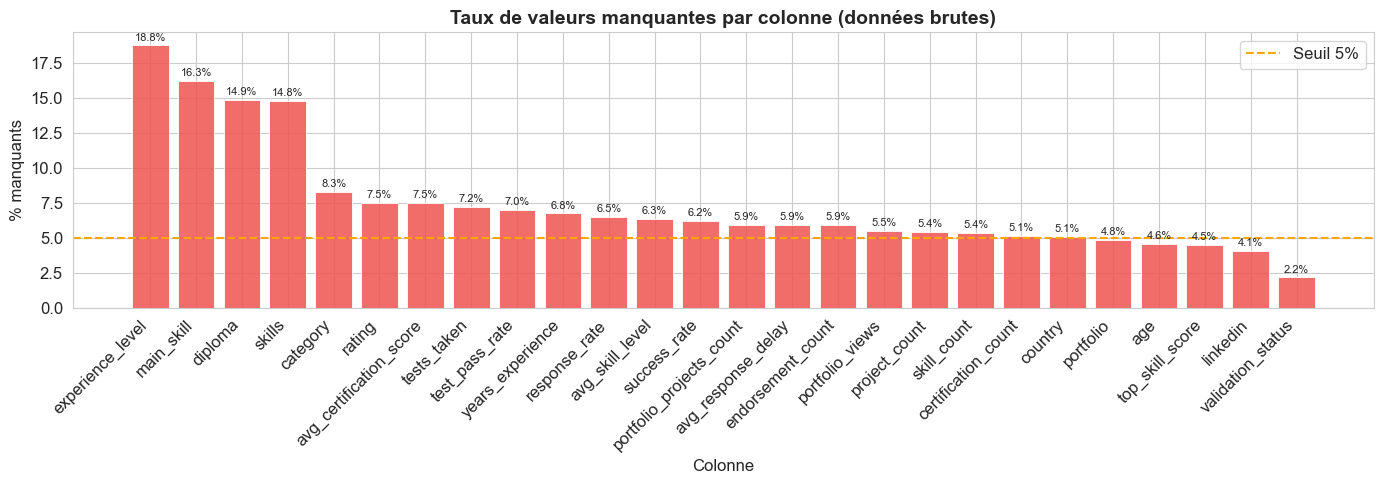

In [3]:
# ================================================================
# 2.2 — Résumé des valeurs manquantes dans les données brutes
# ================================================================
# Avant tout nettoyage, on mesure l'ampleur des problèmes :
#   - Combien de NaN par colonne ?
#   - Quel pourcentage représentent-ils ?
# Ce diagnostic guide les décisions de nettoyage (imputation vs drop).
# ================================================================

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    '% manquants': missing_pct
}).sort_values('% manquants', ascending=False)

print('Valeurs manquantes par colonne (avant nettoyage) :')
print(missing_df[missing_df['Valeurs manquantes'] > 0].to_string())

# Visualisation graphique du taux de manquants
fig, ax = plt.subplots(figsize=(14, 5))
missing_nonzero = missing_pct[missing_pct > 0].sort_values(ascending=False)
bars = ax.bar(missing_nonzero.index, missing_nonzero.values,
              color='#EF5350', edgecolor='white', linewidth=0.7, alpha=0.85)
ax.axhline(y=5, color='orange', linestyle='--', linewidth=1.5, label='Seuil 5%')
ax.set_title('Taux de valeurs manquantes par colonne (données brutes)', fontweight='bold')
ax.set_ylabel('% manquants')
ax.set_xlabel('Colonne')
ax.set_xticklabels(missing_nonzero.index, rotation=45, ha='right')
ax.legend()
# Annoter les barres
for bar, val in zip(bars, missing_nonzero.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. Nettoyage des données (Data Cleaning)

In [4]:
# ================================================================
# SECTION 3.1 — COPIE DE TRAVAIL + SUPPRESSION DES DOUBLONS
# ================================================================
# On travaille toujours sur une COPIE du dataframe brut pour
# préserver les données originales en cas de besoin de rollback.
#
# Doublons : lignes parfaitement identiques générées volontairement
# dans le script (environ 30 lignes). On les supprime par subset
# excluant freelancer_id (car l'id pourrait varier).
# ================================================================

# Copie de travail
df = df_raw.copy()
n_before = len(df)

# Suppression des doublons exacts (toutes colonnes sauf l'id)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'freelancer_id'])
n_after = len(df)
print(f'[1] Doublons supprimés : {n_before - n_after} lignes')
print(f'    Taille restante    : {n_after}')

[1] Doublons supprimés : 30 lignes
    Taille restante    : 2000


In [5]:
# ================================================================
# SECTION 3.2 — NETTOYAGE DE L'ÂGE
# ================================================================
# Problèmes identifiés :
#   - Valeurs textuelles ("vingt-cinq", "28ans")  → NaN
#   - Valeurs numériques hors bornes [18, 65]      → NaN
#   - NaN restants                                 → médiane
# On force le cast en numérique avec errors='coerce' :
# toute valeur non convertible devient automatiquement NaN.
# ================================================================

print('[2] Nettoyage de age')

# Forcer la conversion en numérique (valeurs texte → NaN)
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Compter les aberrants avant correction
n_aberrant_age = ((df['age'] < 18) | (df['age'] > 65)).sum()
print(f'    Valeurs aberrantes [<18 ou >65] : {n_aberrant_age}')

# Mettre NaN si hors bornes réalistes [18, 65]
df.loc[(df['age'] < 18) | (df['age'] > 65), 'age'] = np.nan

# Imputation par la médiane (robuste aux outliers)
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age).astype(int)
print(f'    Médiane utilisée pour imputation : {median_age:.0f} ans')
print(f'    Plage finale : [{df["age"].min()}, {df["age"].max()}]')

[2] Nettoyage de age
    Valeurs aberrantes [<18 ou >65] : 54
    Médiane utilisée pour imputation : 40 ans
    Plage finale : [18, 65]


In [6]:
# ================================================================
# SECTION 3.3 — NETTOYAGE DE YEARS_EXPERIENCE
# ================================================================
# Même logique que l'âge :
#   - Chaînes texte ("cinq", "3 ans")  → pd.to_numeric → NaN
#   - Valeurs aberrantes [-2, 50]      → NaN
#   - NaN                              → médiane
# ================================================================

print('[3] Nettoyage de years_experience')
df['years_experience'] = pd.to_numeric(df['years_experience'], errors='coerce')
n_aberrant_exp = ((df['years_experience'] < 0) | (df['years_experience'] > 45)).sum()
print(f'    Aberrants hors [0, 45] : {n_aberrant_exp}')
df.loc[(df['years_experience'] < 0) | (df['years_experience'] > 45), 'years_experience'] = np.nan
median_exp = df['years_experience'].median()
df['years_experience'] = df['years_experience'].fillna(median_exp)
print(f'    Médiane utilisée : {median_exp:.1f} ans')

[3] Nettoyage de years_experience
    Aberrants hors [0, 45] : 57
    Médiane utilisée : 15.6 ans


In [7]:
# ================================================================
# SECTION 3.4 — NORMALISATION DES COLONNES CATÉGORIELLES
# ================================================================
# Les colonnes experience_level, diploma, country, category
# contiennent des variantes de casse et espaces parasites :
#   "SENIOR" → "Senior", " Canada" → "Canada", "DATA" → "Data"
#
# Stratégie : strip() + title() pour uniformiser, puis mapping
# explicite des abréviations connues (Jr → Junior, Sr → Senior).
# Les valeurs inconnues / vides sont remplacées par "Inconnu" ou "Autre".
# ================================================================

print('[4] Nettoyage de experience_level')
exp_mapping = {
    'Junior': 'Junior', 'junior': 'Junior', 'Jr': 'Junior',
    'Mid': 'Mid', 'mid': 'Mid', 'Confirmé': 'Mid',
    'Senior': 'Senior', 'senior': 'Senior', 'SENIOR': 'Senior', 'Sr': 'Senior'
}
df['experience_level'] = (df['experience_level']
    .astype(str).str.strip()
    .map(exp_mapping)
    .fillna('Inconnu'))
print(f'    Distribution : {df["experience_level"].value_counts().to_dict()}')

print('\n[5] Nettoyage de diploma')
diploma_mapping = {
    'Licence': 'Licence', 'licence': 'Licence', 'Bac+3': 'Licence', 'bac+3': 'Licence',
    'Master': 'Master', 'master': 'Master', 'MASTER': 'Master', 'Bac+5': 'Master',
    'Bac +5': 'Master',
    'Doctorat': 'Doctorat', 'PhD': 'Doctorat',
    'Autodidacte': 'Autodidacte',
}
df['diploma'] = (df['diploma']
    .astype(str).str.strip()
    .map(diploma_mapping)
    .fillna('Inconnu'))
print(f'    Distribution : {df["diploma"].value_counts().to_dict()}')

print('\n[6] Nettoyage de country')
df['country'] = df['country'].astype(str).str.strip().str.title()
df['country'] = df['country'].replace({'Nan': 'Inconnu', 'None': 'Inconnu', '': 'Inconnu'})
print(f'    Pays uniques : {df["country"].nunique()}')

print('\n[7] Nettoyage de category')
df['category'] = df['category'].astype(str).str.strip().str.title()
df['category'] = df['category'].replace({'Nan': 'Autre', 'None': 'Autre', '': 'Autre'})
print(f'    Catégories : {df["category"].value_counts().to_dict()}')

[4] Nettoyage de experience_level
    Distribution : {'Senior': 572, 'Mid': 528, 'Junior': 525, 'Inconnu': 375}

[5] Nettoyage de diploma
    Distribution : {'Master': 624, 'Licence': 614, 'Doctorat': 314, 'Inconnu': 298, 'Autodidacte': 150}

[6] Nettoyage de country
    Pays uniques : 13

[7] Nettoyage de category
    Catégories : {'Web': 501, 'Data': 359, 'Autre': 322, 'Design': 316, 'Devops': 176, 'Mobile': 173, 'Marketing': 153}


In [8]:
# ================================================================
# SECTION 3.5 — NETTOYAGE DES COLONNES BOOLÉENNES (portfolio, linkedin)
# ================================================================
# Ces colonnes contiennent des représentations hétérogènes d'un
# booléen : "Oui", "Yes", "1", "TRUE" → 1
#           "Non", "No",  "0", "FALSE" → 0
# On crée une fonction clean_binary() réutilisable.
# Les NaN sont remplacés par 0 (absence = pas de portfolio/linkedin).
# ================================================================

print('[8] Nettoyage des colonnes booléennes (portfolio, linkedin)')

def clean_binary(series):
    """
    Convertit une colonne contenant des variantes textuelles
    d'un booléen en entier 0 ou 1.
    
    Valeurs → 1 : oui, yes, 1, true
    Valeurs → 0 : non, no, 0, false
    Autres  → NaN (sera imputé à 0)
    """
    s = series.astype(str).str.strip().str.lower()
    mapping = {
        'oui': 1, 'yes': 1, '1': 1, 'true': 1,
        'non': 0, 'no': 0, '0': 0, 'false': 0,
        'nan': np.nan, 'none': np.nan
    }
    return s.map(mapping)

df['portfolio'] = clean_binary(df['portfolio']).fillna(0).astype(int)
df['linkedin']  = clean_binary(df['linkedin']).fillna(0).astype(int)
print(f'    Portfolio : {df["portfolio"].value_counts().to_dict()}')
print(f'    LinkedIn  : {df["linkedin"].value_counts().to_dict()}')

[8] Nettoyage des colonnes booléennes (portfolio, linkedin)
    Portfolio : {0: 1001, 1: 999}
    LinkedIn  : {1: 1027, 0: 973}


In [9]:
# ================================================================
# SECTION 3.6 — NETTOYAGE DES COLONNES NUMÉRIQUES
# ================================================================
# Pour chaque colonne numérique, on définit des bornes réalistes.
# Toute valeur hors borne est remplacée par NaN, puis imputée
# par la MÉDIANE de la colonne (plus robuste que la moyenne face
# aux outliers résiduels).
#
# Les bornes sont choisies selon la signification métier :
#   - rating        : [0, 5]
#   - success_rate  : [0, 100] (%)
#   - avg_skill_level: [1, 5]
#   etc.
# ================================================================

print('[9] Nettoyage des colonnes numériques avec bornes réalistes')

# Définition des bornes (min, max) pour chaque colonne
bounds = {
    'skill_count'             : (0, 20),
    'avg_skill_level'         : (1, 5),
    'top_skill_score'         : (1, 5),
    'project_count'           : (0, 200),
    'rating'                  : (0, 5),
    'success_rate'            : (0, 100),
    'certification_count'     : (0, 20),
    'response_rate'           : (0, 100),
    'avg_response_delay'      : (0, 100),
    'endorsement_count'       : (0, 30),
    'avg_certification_score' : (0, 100),
    'test_pass_rate'          : (0, 100),
    'tests_taken'             : (0, 30),
    'portfolio_views'         : (0, 1000),
    'portfolio_projects_count': (0, 30),
}

stats_clean = []
for col, (lo, hi) in bounds.items():
    # Forcer le type numérique (sécurité supplémentaire)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Nombre d'outliers détectés
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    # Remplacer les hors-bornes par NaN
    df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
    # Imputation par la médiane
    med = df[col].median()
    df[col] = df[col].fillna(med)
    stats_clean.append({'Colonne': col, 'Aberrants': n_out,
                        'Médiane': round(med, 2),
                        'Min final': df[col].min(),
                        'Max final': df[col].max()})

stats_df = pd.DataFrame(stats_clean)
print(stats_df.to_string(index=False))

[9] Nettoyage des colonnes numériques avec bornes réalistes
                 Colonne  Aberrants  Médiane  Min final  Max final
             skill_count         44     6.00        0.0       12.0
         avg_skill_level         71     3.04        1.0        5.0
         top_skill_score          0     3.00        1.0        5.0
           project_count         47    76.00        0.0      150.0
                  rating         45     2.52        0.0        5.0
            success_rate         63    49.10        0.1      100.0
     certification_count         58     7.00        0.0       15.0
           response_rate          0    49.40        0.0      100.0
      avg_response_delay         56    37.10        0.6       72.0
       endorsement_count         55     7.00        0.0       15.0
 avg_certification_score         57    49.20        0.0      100.0
          test_pass_rate         58    49.10        0.0      100.0
             tests_taken         66    10.00        0.0       20.0
  

In [10]:
# ================================================================
# SECTION 3.7 — SUPPRESSION DE LA TARGET MANQUANTE + COLONNES INUTILES
# ================================================================
# On supprime les lignes sans validation_status (cible inconnue,
# environ 2% du dataset) car on ne peut pas les utiliser pour
# l'apprentissage supervisé.
# On supprime aussi les colonnes non pertinentes pour les modèles :
#   - freelancer_id : identifiant non informatif
#   - skills        : texte brut difficile à encoder directement
#   - main_skill    : dérivé des skills (redondant)
# ================================================================

print('[10] Traitement final de la cible et suppression des colonnes inutiles')

# Supprimer les lignes sans target
n_before = len(df)
df = df.dropna(subset=['validation_status'])
df['validation_status'] = df['validation_status'].astype(int)
print(f'    Lignes sans target supprimées : {n_before - len(df)}')

# Supprimer colonnes non pertinentes pour la modélisation
cols_drop = ['freelancer_id', 'skills', 'main_skill']
df = df.drop(columns=cols_drop, errors='ignore')
print(f'    Colonnes supprimées : {cols_drop}')
print(f'\n    Dataset final après nettoyage : {df.shape}')
print(f'    Valeurs manquantes restantes  : {df.isnull().sum().sum()}')

# Distribution de la cible
vc = df['validation_status'].value_counts()
print(f'\n    Distribution de la cible :')
print(f'      Classe 0 (Revue manuelle) : {vc.get(0, 0)} ({vc.get(0,0)/len(df)*100:.1f}%)')
print(f'      Classe 1 (Validé auto)    : {vc.get(1, 0)} ({vc.get(1,0)/len(df)*100:.1f}%)')

[10] Traitement final de la cible et suppression des colonnes inutiles
    Lignes sans target supprimées : 43
    Colonnes supprimées : ['freelancer_id', 'skills', 'main_skill']

    Dataset final après nettoyage : (1957, 24)
    Valeurs manquantes restantes  : 0

    Distribution de la cible :
      Classe 0 (Revue manuelle) : 710 (36.3%)
      Classe 1 (Validé auto)    : 1247 (63.7%)


---
## 4. Feature Engineering

In [11]:
# ================================================================
# SECTION 4 — FEATURE ENGINEERING
# ================================================================
# On crée 8 nouvelles variables dérivées pour enrichir le signal
# fourni aux modèles ML. Ces features capturent des interactions
# et des ratios non linéaires que les modèles auraient du mal
# à inférer seuls depuis les colonnes brutes.
#
# Features créées :
#   1. experience_skill_ratio   : compétences par année d'expérience
#   2. experience_age_ratio     : expérience rapportée à l'âge
#   3. profile_completeness     : taux de présence des éléments clés
#   4. certification_quality    : score certification × nb certifs
#   5. engagement_score         : portfolio views × taux de réponse
#   6. credibility_score        : endorsements + certifications normalisés
#   7. activity_score           : projets + tests passés (activité globale)
#   8. quality_score            : score composite [0-100] utilisé aussi
#                                  comme feature et comme indicateur métier
# ================================================================

print('Création des features dérivées...')

# --- 1. Ratio compétences / expérience ---
# Mesure la densité de compétences par année d'expérience.
# Un freelancer avec 10 skills et 2 ans est "plus dense" qu'avec 10 ans.
df['experience_skill_ratio'] = (
    df['skill_count'] / (df['years_experience'] + 1)  # +1 pour éviter la division par 0
).round(4)

# --- 2. Ratio expérience / âge ---
# Indique la proportion de la vie active consacrée au travail.
df['experience_age_ratio'] = (
    df['years_experience'] / (df['age'] + 1)
).round(4)

# --- 3. Score de complétude du profil ---
# Somme binaire de 6 indicateurs importants de complétude :
# portfolio présent, linkedin présent, certifications, tests passés,
# projets réalisés, et vues portfolio (preuve de visibilité).
df['profile_completeness'] = (
    df['portfolio'].clip(0, 1) +
    df['linkedin'].clip(0, 1) +
    (df['certification_count'] > 0).astype(int) +
    (df['tests_taken'] > 0).astype(int) +
    (df['project_count'] > 0).astype(int) +
    (df['portfolio_views'] > 0).astype(int)
).astype(float)  # valeur entre 0 et 6

# --- 4. Qualité des certifications ---
# Produit normalisé entre le score moyen des certifications et leur nombre.
# Un freelancer avec peu de certifications très bien notées est favorisé.
df['certification_quality'] = (
    (df['avg_certification_score'] / 100) * df['certification_count']
).round(4)

# --- 5. Score d'engagement ---
# Mesure l'activité et la visibilité du freelancer :
# vues portfolio normalisées × taux de réponse normalisé.
df['engagement_score'] = (
    (df['portfolio_views'] / 1000) * (df['response_rate'] / 100)
).round(4)

# --- 6. Score de crédibilité ---
# Combine endorsements (validation par pairs) et certifications.
df['credibility_score'] = (
    (df['endorsement_count'] / 30) +
    (df['certification_count'] / 20)
).round(4)

# --- 7. Score d'activité ---
# Combine le nombre de projets réalisés et les tests passés.
df['activity_score'] = (
    np.log1p(df['project_count']) +    # log pour atténuer l'effet des très gros comptes
    (df['tests_taken'] / 20)
).round(4)

# --- 8. Score de qualité composite [0-100] ---
# Score métier final utilisé pour la décision à 3 niveaux.
# Pondération reflétant l'importance relative selon les règles métier.
quality_score = (
    df['rating']               / 5   * 20 +   # Note (20 pts) — facteur le plus important
    df['avg_skill_level']      / 5   * 15 +   # Niveau de compétences (15 pts)
    df['success_rate']         / 100 * 15 +   # Taux de succès (15 pts)
    df['test_pass_rate']       / 100 * 10 +   # Tests réussis (10 pts)
    df['avg_certification_score']/100* 10 +   # Score certifications (10 pts)
    df['profile_completeness'] / 6   * 10 +   # Complétude profil (10 pts)
    df['credibility_score']    / 2   *  5 +   # Crédibilité (5 pts)
    df['engagement_score']           *  5 +   # Engagement (5 pts)
    df['activity_score']       / 5   *  5 +   # Activité (5 pts)
    df['experience_skill_ratio']/ 3  *  5     # Densité skills/exp (5 pts)
).clip(0, 100)

df['quality_score'] = quality_score.round(2)

# Résumé des features créées
new_features = ['experience_skill_ratio', 'experience_age_ratio',
                'profile_completeness', 'certification_quality',
                'engagement_score', 'credibility_score',
                'activity_score', 'quality_score']
print(f'\n  {len(new_features)} features créées :')
for f in new_features:
    print(f'    {f:30s} → moy={df[f].mean():.2f}, std={df[f].std():.2f}')

Création des features dérivées...

  8 features créées :
    experience_skill_ratio         → moy=0.63, std=0.92
    experience_age_ratio           → moy=0.40, std=0.27
    profile_completeness           → moy=4.90, std=0.78
    certification_quality          → moy=3.66, std=3.17
    engagement_score               → moy=0.12, std=0.11
    credibility_score              → moy=0.62, std=0.26
    activity_score                 → moy=4.57, std=0.96
    quality_score                  → moy=52.29, std=8.69


In [12]:
# ================================================================
# SECTION 4.2 — ENCODAGE DES VARIABLES CATÉGORIELLES
# ================================================================
# Les modèles ML nécessitent des entrées numériques.
# On utilise pd.get_dummies() (One-Hot Encoding) pour les colonnes
# catégorielles : experience_level, diploma, country, category.
#
# One-Hot Encoding crée une colonne binaire par modalité.
# drop_first=True évite la multicolinéarité (k-1 colonnes pour k classes).
# ================================================================

print('Encodage One-Hot des variables catégorielles...')

cat_cols = ['experience_level', 'diploma', 'country', 'category']
print(f'  Colonnes à encoder : {cat_cols}')
print(f'  Taille avant encoding : {df.shape}')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded = df_encoded.astype(float)  # Uniformiser en float pour sklearn

print(f'  Taille après encoding : {df_encoded.shape}')
print(f'  Nouvelles colonnes créées : {df_encoded.shape[1] - df.shape[1] + len(cat_cols)}')

Encodage One-Hot des variables catégorielles...
  Colonnes à encoder : ['experience_level', 'diploma', 'country', 'category']
  Taille avant encoding : (1957, 32)
  Taille après encoding : (1957, 53)
  Nouvelles colonnes créées : 25


---
## 5. Analyse Exploratoire (EDA)

In [13]:
# ================================================================
# SECTION 5.1 — STATISTIQUES DESCRIPTIVES
# ================================================================
# Les statistiques descriptives donnent une vue d'ensemble rapide :
#   - count  : nombre de valeurs non nulles
#   - mean   : moyenne arithmétique
#   - std    : écart-type (dispersion)
#   - min/max: valeurs extrêmes
#   - 50%    : médiane
# Après nettoyage, on s'attend à des ranges cohérents.
# ================================================================

print('Statistiques descriptives des features numériques principales :')
main_num_cols = ['age', 'years_experience', 'skill_count', 'avg_skill_level',
                 'project_count', 'rating', 'success_rate', 'certification_count',
                 'endorsement_count', 'avg_certification_score', 'test_pass_rate',
                 'quality_score']
df[main_num_cols].describe().round(2)

Statistiques descriptives des features numériques principales :


,age,years_experience,skill_count,avg_skill_level,project_count,rating,success_rate,certification_count,endorsement_count,avg_certification_score,test_pass_rate,quality_score
count,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00,1957.00
mean,40.62,15.19,5.97,3.00,76.21,2.50,49.58,7.47,7.46,49.26,49.78,52.29
std,12.93,8.18,3.72,1.10,42.34,1.35,27.13,4.44,4.37,27.33,27.60,8.69
min,18.00,0.00,0.00,1.00,0.00,0.00,0.10,0.00,0.00,0.00,0.00,25.38
25%,30.00,8.50,3.00,2.12,42.00,1.42,28.00,4.00,4.00,27.60,27.20,46.44
50%,40.00,15.60,6.00,3.04,76.00,2.52,49.10,7.00,7.00,49.20,49.10,52.22
75%,51.00,21.80,9.00,3.87,112.00,3.59,71.20,11.00,11.00,71.10,73.20,58.27
max,65.00,30.00,12.00,5.00,150.00,5.00,100.00,15.00,15.00,100.00,100.00,82.80


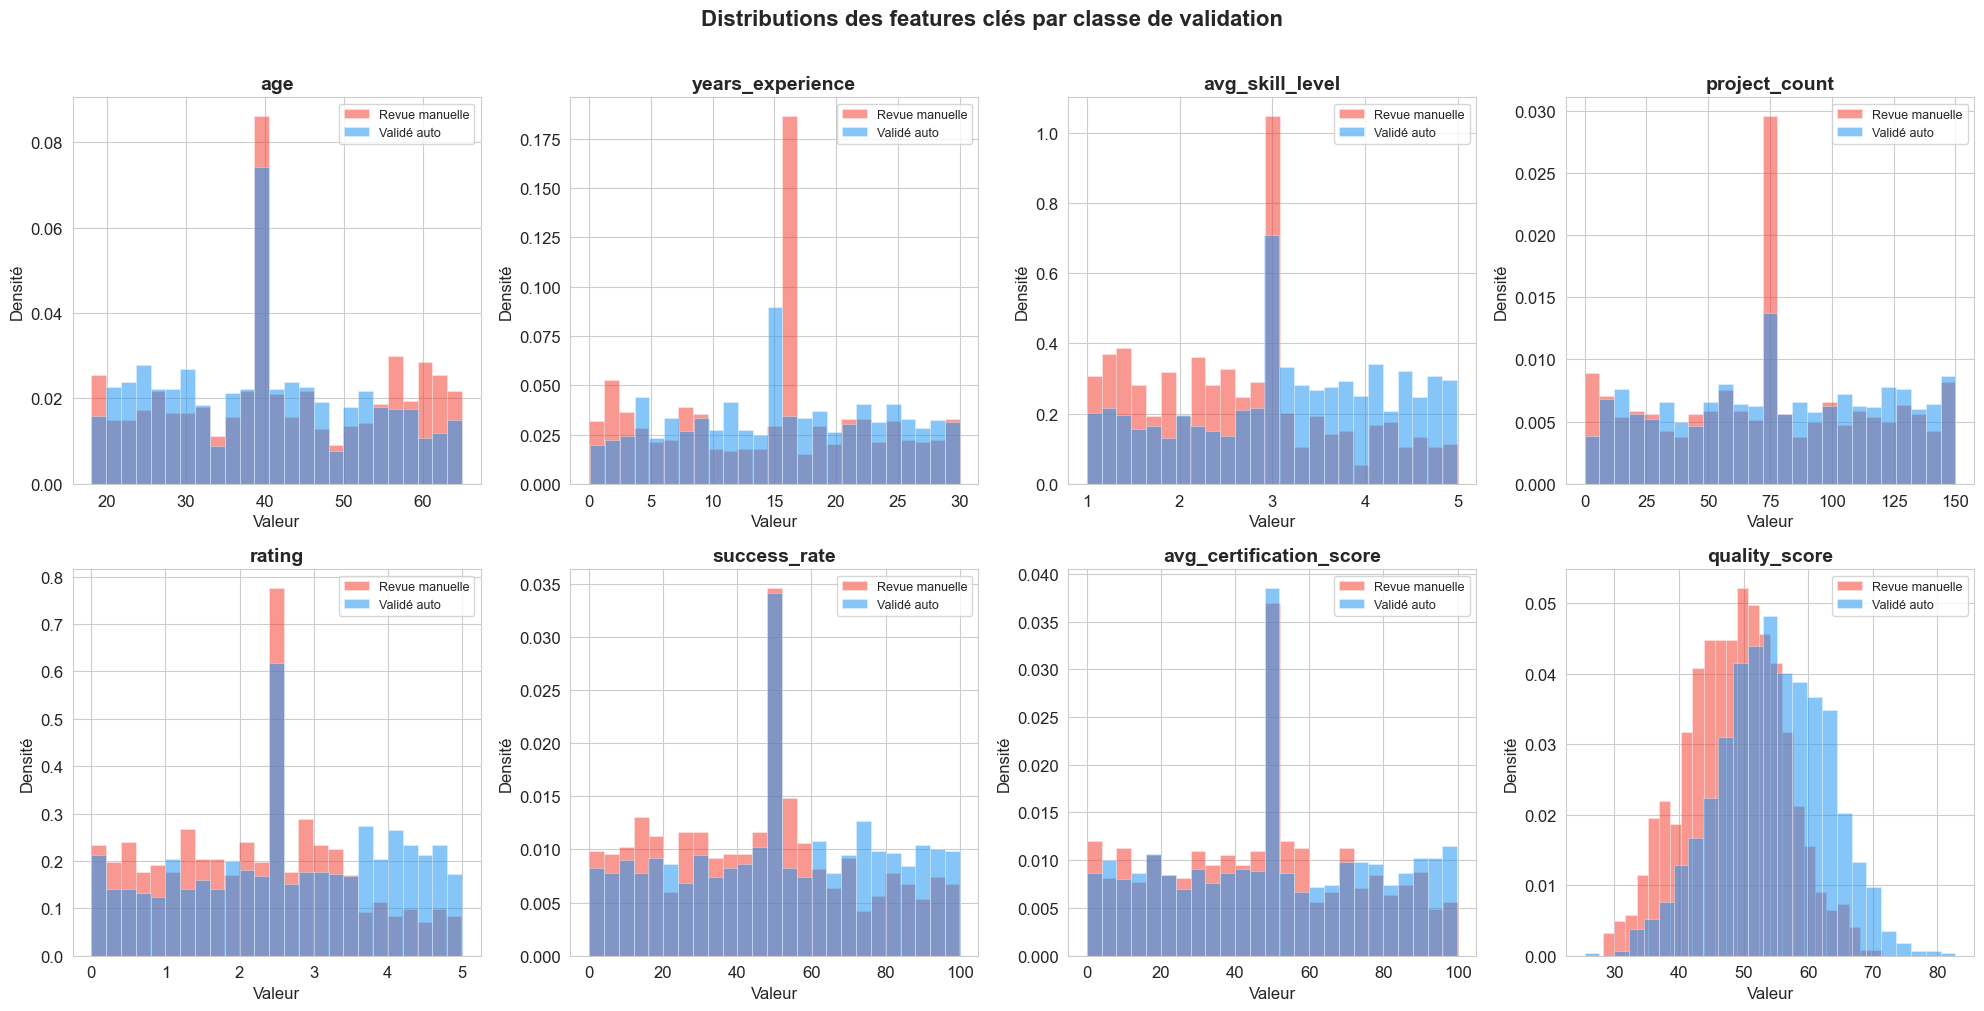

In [14]:
# ================================================================
# SECTION 5.2 — DISTRIBUTION DES FEATURES NUMÉRIQUES CLÉS
# ================================================================
# Les histogrammes révèlent :
#   - La forme de la distribution (normale, asymétrique, bimodale)
#   - La présence éventuelle d'outliers post-nettoyage
#   - La séparation entre les classes 0 et 1 (signal discriminant)
# On colore par validation_status pour voir si les distributions
# diffèrent entre validés (1) et refusés (0).
# ================================================================

features_to_plot = ['age', 'years_experience', 'avg_skill_level',
                    'project_count', 'rating', 'success_rate',
                    'avg_certification_score', 'quality_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    for cls, color, lbl in [(0, COLOR_NEG, 'Revue manuelle'), (1, COLOR_POS, 'Validé auto')]:
        subset = df[df['validation_status'] == cls][feat]
        ax.hist(subset, bins=25, alpha=0.55, color=color, edgecolor='white',
                linewidth=0.4, label=lbl, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)

plt.suptitle('Distributions des features clés par classe de validation',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

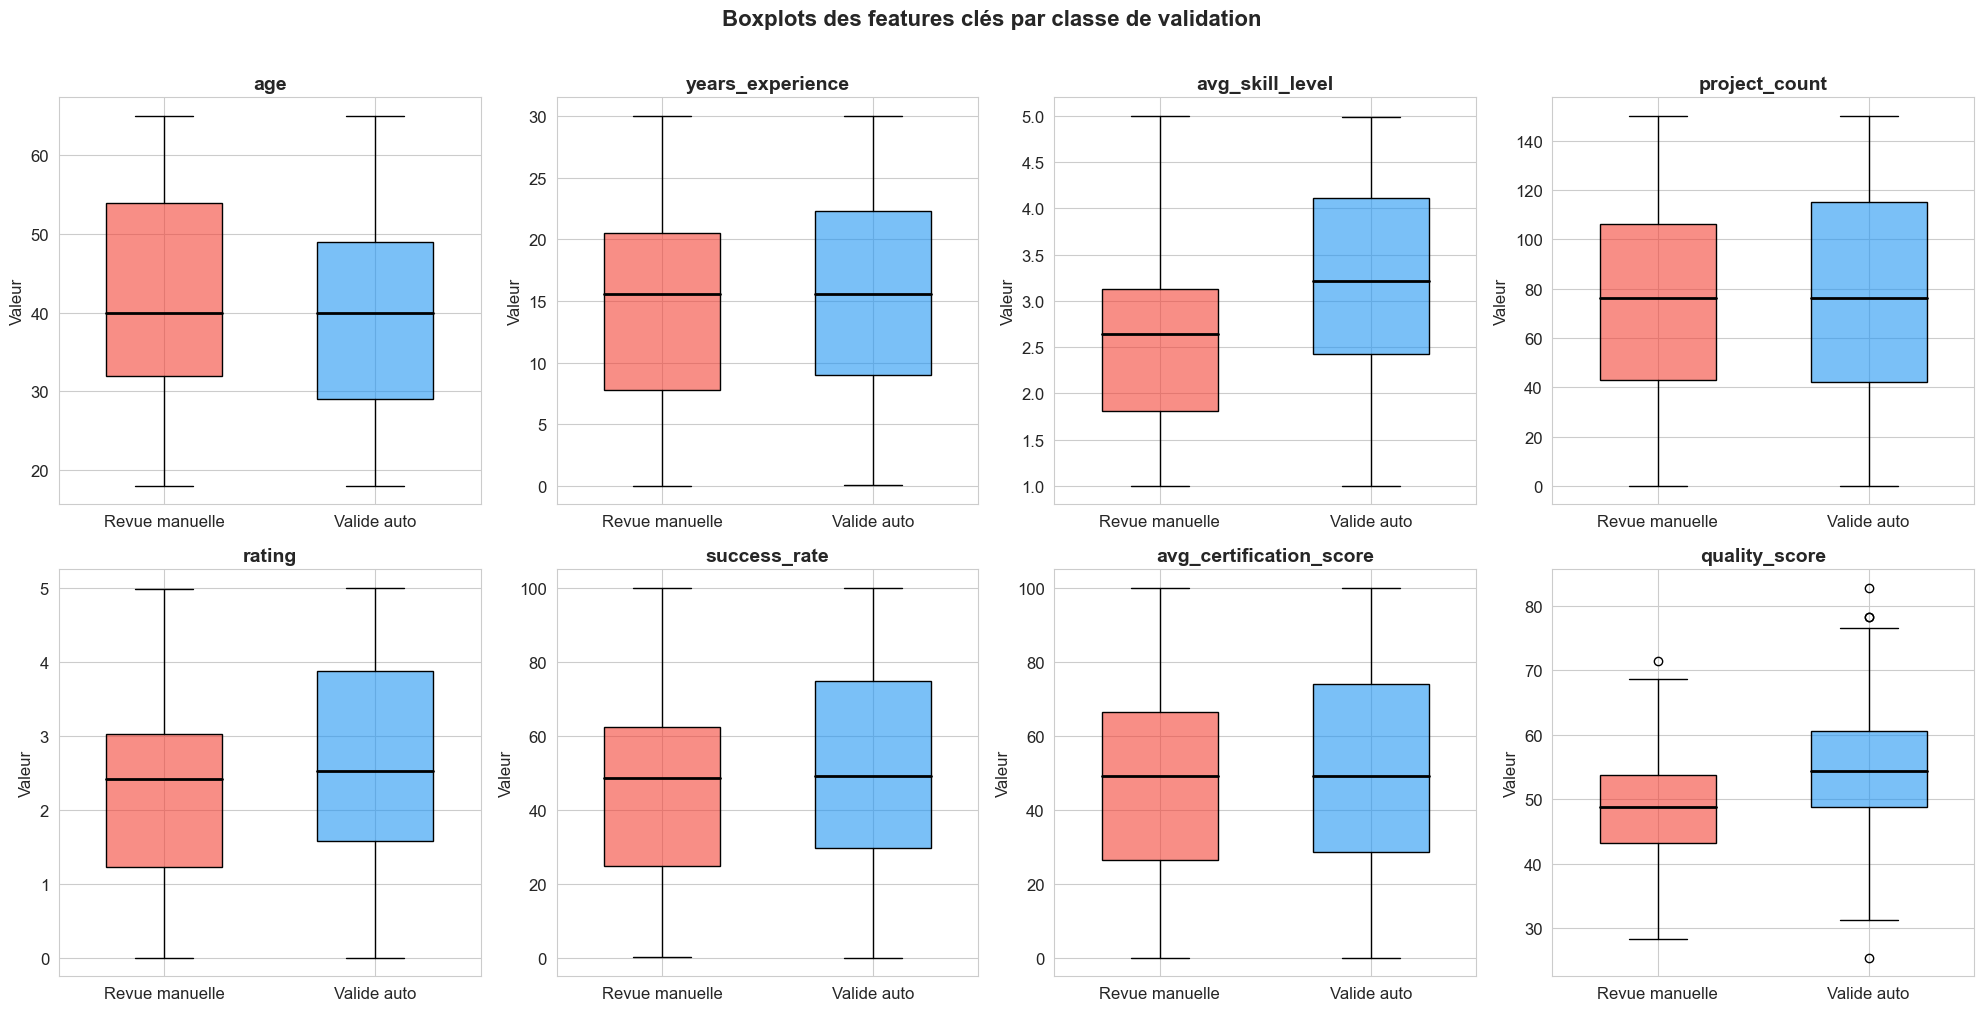

In [15]:
# ================================================================
# SECTION 5.3 — BOXPLOTS PAR CLASSE
# ================================================================
# Les boxplots montrent :
#   - La médiane (ligne centrale)
#   - L'IQR (boîte = 25e–75e percentile)
#   - Les moustaches (1.5×IQR)
#   - Les points = outliers individuels
# Si les boîtes des deux classes se chevauchent peu
# → la feature est discriminante pour la prédiction.
# ================================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    data_cls0 = df[df['validation_status'] == 0][feat].dropna()
    data_cls1 = df[df['validation_status'] == 1][feat].dropna()
    bp = ax.boxplot([data_cls0, data_cls1],
                    patch_artist=True,
                    labels=['Revue manuelle', 'Valide auto'],
                    medianprops=dict(color='black', linewidth=2),
                    widths=0.55)
    bp['boxes'][0].set_facecolor(COLOR_NEG + '99')  # alpha via hex
    bp['boxes'][1].set_facecolor(COLOR_POS + '99')
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Valeur')

plt.suptitle('Boxplots des features clés par classe de validation',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

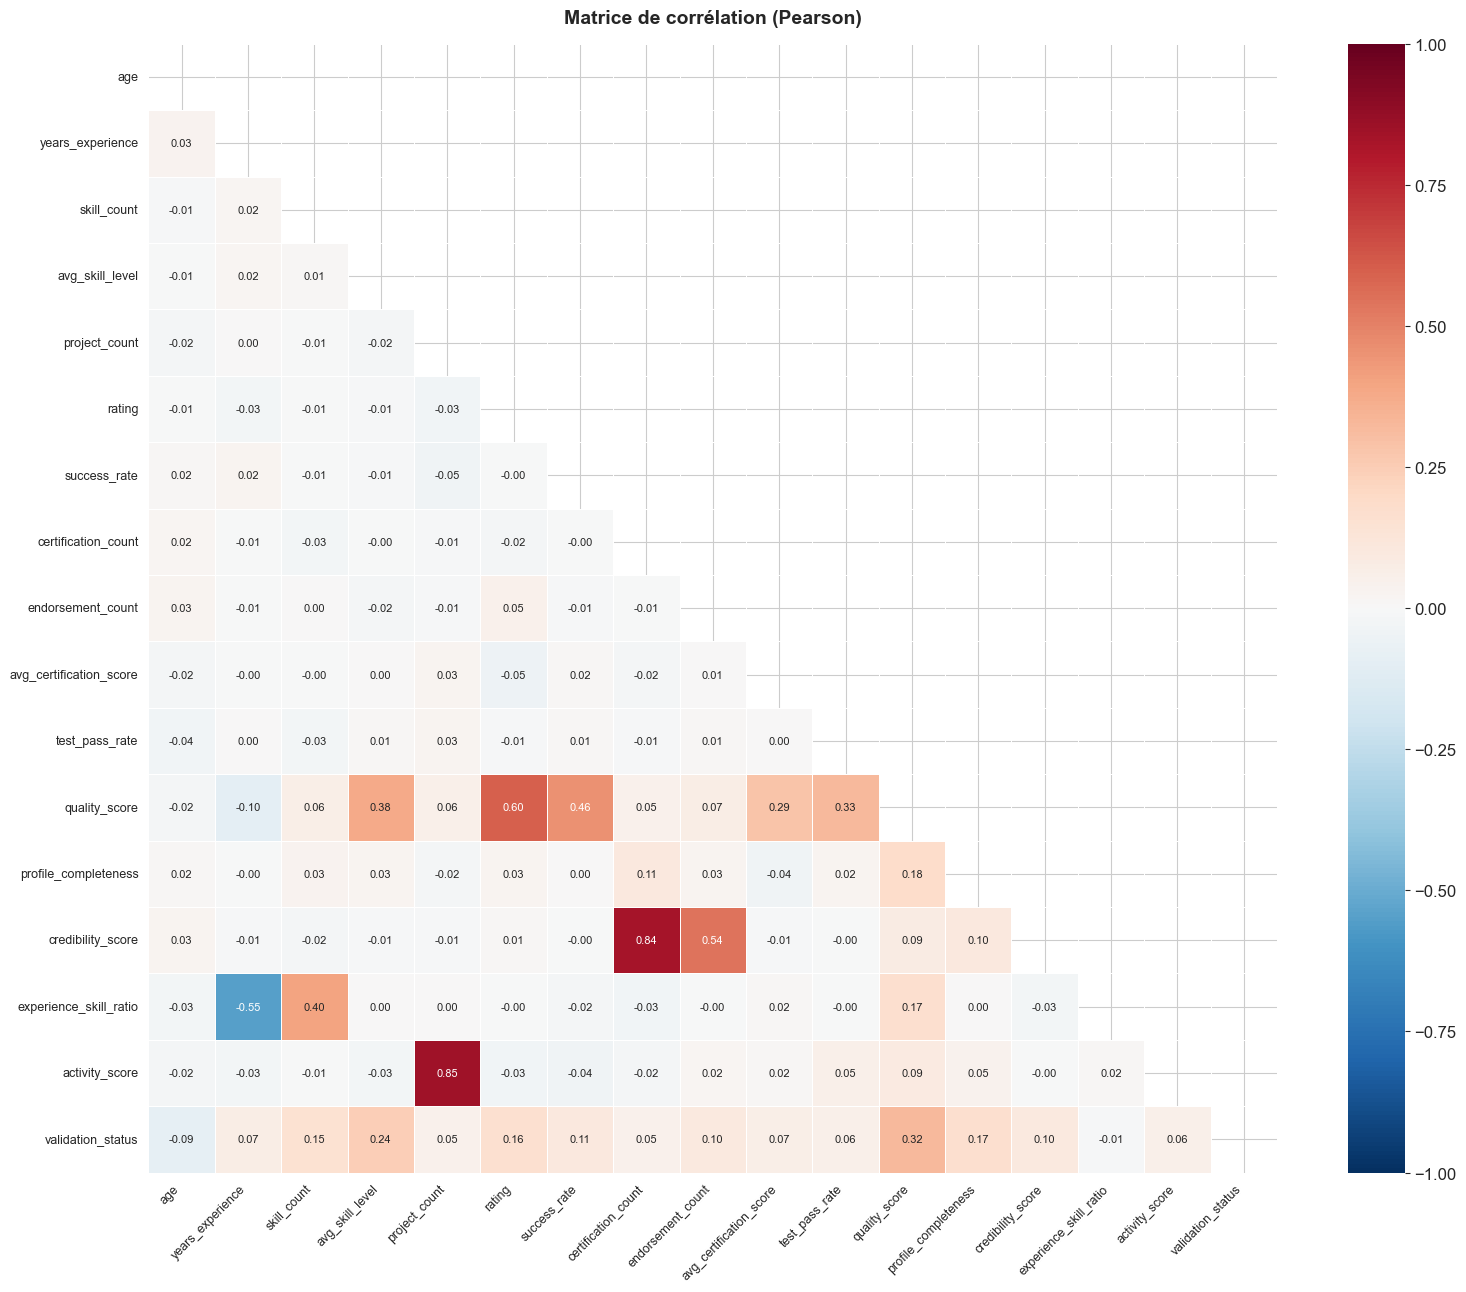


Top 10 features les plus corrélées avec validation_status :
  quality_score                       → |r| = 0.324
  avg_skill_level                     → |r| = 0.243
  profile_completeness                → |r| = 0.169
  rating                              → |r| = 0.163
  skill_count                         → |r| = 0.150
  success_rate                        → |r| = 0.107
  endorsement_count                   → |r| = 0.098
  credibility_score                   → |r| = 0.097
  age                                 → |r| = 0.093
  years_experience                    → |r| = 0.071


In [16]:
# ================================================================
# SECTION 5.4 — HEATMAP DE CORRÉLATION
# ================================================================
# La matrice de corrélation de Pearson mesure les relations linéaires
# entre features numériques.
#   - r ≈ +1 : corrélation positive forte
#   - r ≈ -1 : corrélation négative forte
#   - r ≈  0 : pas de relation linéaire
#
# Utilité pour la modélisation :
#   - Features très corrélées entre elles → redondance potentielle
#   - Features corrélées avec validation_status → bon prédicteur
# On masque le triangle inférieur pour plus de lisibilité.
# ================================================================

# Sélection des colonnes numériques principales pour la heatmap
heatmap_cols = ['age', 'years_experience', 'skill_count', 'avg_skill_level',
                'project_count', 'rating', 'success_rate', 'certification_count',
                'endorsement_count', 'avg_certification_score', 'test_pass_rate',
                'quality_score', 'profile_completeness', 'credibility_score',
                'experience_skill_ratio', 'activity_score', 'validation_status']

corr_matrix = df[heatmap_cols].corr()

# Masque pour le triangle inférieur (évite la redondance)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdBu_r',         # rouge = corrélation positive, bleu = négative
            vmin=-1, vmax=1,
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# Corrélations avec la cible (validation_status)
target_corr = corr_matrix['validation_status'].drop('validation_status').abs().sort_values(ascending=False)
print('\nTop 10 features les plus corrélées avec validation_status :')
for feat, val in target_corr.head(10).items():
    print(f'  {feat:35s} → |r| = {val:.3f}')

Features sélectionnées pour le pairplot : ['quality_score', 'avg_skill_level', 'profile_completeness', 'rating', 'skill_count']


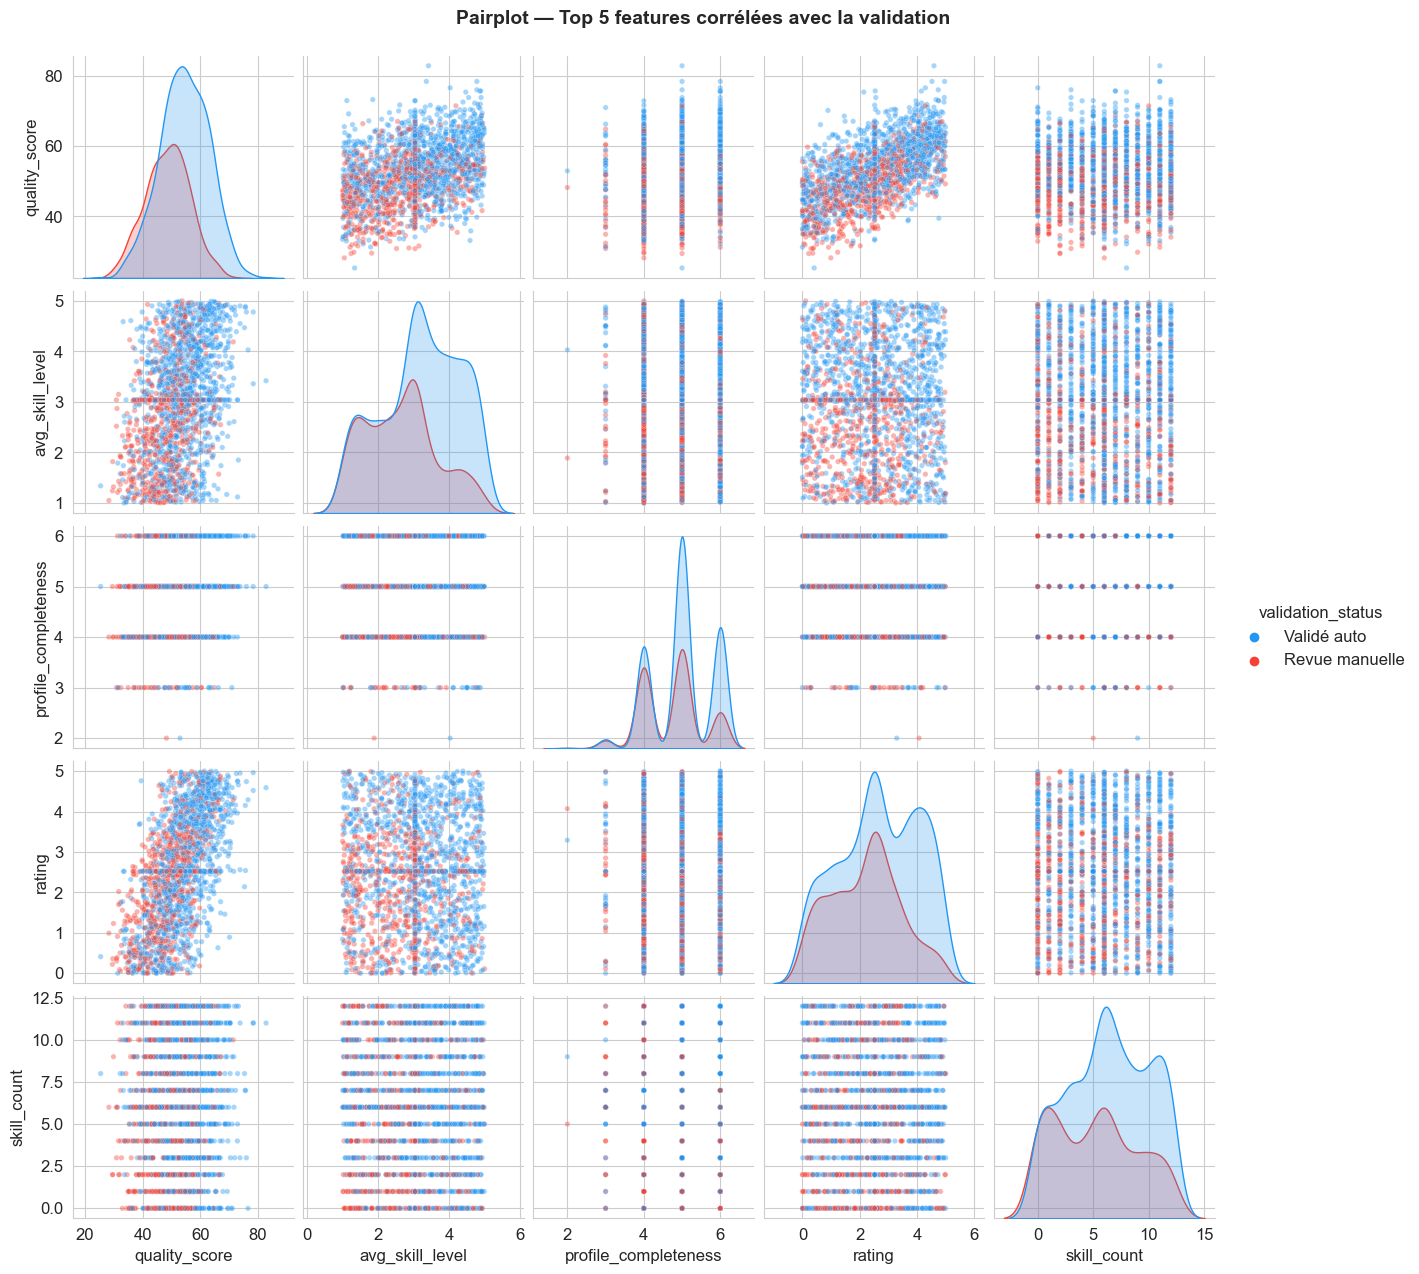

In [17]:
# ================================================================
# SECTION 5.5 — PAIRPLOT DES 5 MEILLEURES FEATURES
# ================================================================
# Le pairplot trace toutes les combinaisons de scatter plots
# entre features sélectionnées, colorées par classe.
# Il permet de repérer visuellement des frontières de décision
# et des clusters naturels dans les données.
# On limite à 5 features pour garder le graphique lisible.
# ================================================================

top5 = target_corr.head(5).index.tolist()
print(f'Features sélectionnées pour le pairplot : {top5}')

pairplot_df = df[top5 + ['validation_status']].copy()
pairplot_df['validation_status'] = pairplot_df['validation_status'].map(
    {0: 'Revue manuelle', 1: 'Validé auto'})

g = sns.pairplot(pairplot_df, hue='validation_status',
                 palette={'Revue manuelle': COLOR_NEG, 'Validé auto': COLOR_POS},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.figure.suptitle('Pairplot — Top 5 features corrélées avec la validation', y=1.02,
                   fontsize=14, fontweight='bold')
plt.show()

---
## 6. ACP (Analyse en Composantes Principales)

In [18]:
# ================================================================
# SECTION 6.1 — PRÉPARATION POUR L'ACP
# ================================================================
# L'ACP (PCA en sklearn) est sensible aux échelles :
# une feature avec de grandes valeurs (ex: project_count ≈ 100)
# dominerait une feature à petite échelle (ex: rating ≈ 2.5).
# On standardise donc toutes les features AVANT de lancer l'ACP
# (moyenne 0, écart-type 1) via StandardScaler.
#
# On travaille sur le dataframe encodé (toutes colonnes numériques).
# ================================================================

print('Préparation des données pour l ACP...')

# Séparation features / cible
X_pca_all = df_encoded.drop(columns=['validation_status'])
y_pca     = df_encoded['validation_status']

# Standardisation (obligatoire pour PCA)
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca_all)

print(f'  Dimensions des données : {X_pca_scaled.shape}')
print(f'  Moyenne après scaling  : {X_pca_scaled.mean():.6f} (≈ 0)')
print(f'  Std après scaling      : {X_pca_scaled.std():.6f} (≈ 1)')

Préparation des données pour l ACP...
  Dimensions des données : (1957, 52)
  Moyenne après scaling  : -0.000000 (≈ 0)
  Std après scaling      : 1.000000 (≈ 1)


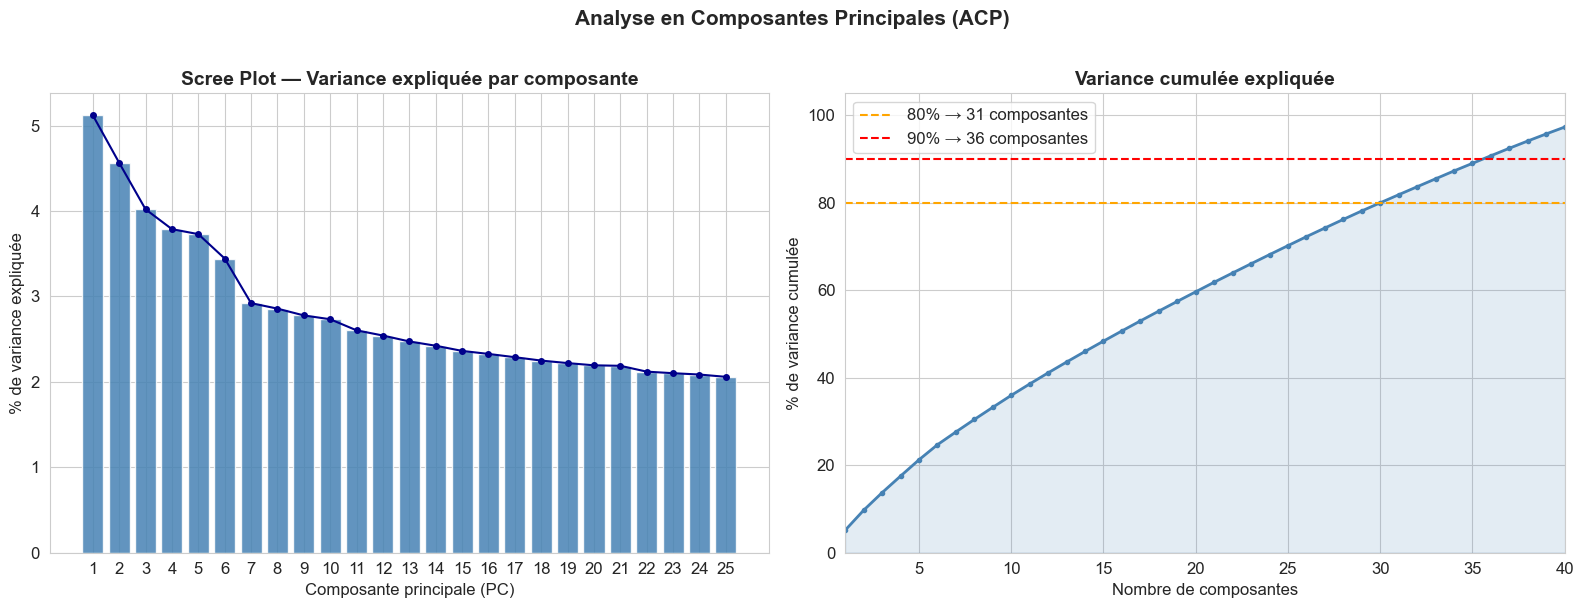

  → 80% de variance expliquée avec 31 composantes
  → 90% de variance expliquée avec 36 composantes


In [19]:
# ================================================================
# SECTION 6.2 — SCREE PLOT (variance expliquée)
# ================================================================
# Le scree plot montre la variance expliquée par chaque composante.
# On cherche le "coude" (elbow) : le point où ajouter une composante
# supplémentaire n'apporte plus beaucoup d'information.
# La variance cumulée indique combien de composantes suffisent pour
# représenter X% de l'information totale du dataset.
# ================================================================

# ACP complète pour le scree plot
pca_full = PCA(random_state=42)
pca_full.fit(X_pca_scaled)

explained  = pca_full.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

# Trouver le nombre de composantes pour 80% et 90% de variance
n_80 = np.argmax(cumulative >= 80) + 1
n_90 = np.argmax(cumulative >= 90) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Scree plot (variance individuelle) ---
n_show = min(25, len(explained))
ax1.bar(range(1, n_show+1), explained[:n_show],
        color='steelblue', edgecolor='white', alpha=0.85)
ax1.plot(range(1, n_show+1), explained[:n_show],
         'o-', color='darkblue', markersize=4, linewidth=1.5)
ax1.set_title('Scree Plot — Variance expliquée par composante',
              fontweight='bold')
ax1.set_xlabel('Composante principale (PC)')
ax1.set_ylabel('% de variance expliquée')
ax1.set_xticks(range(1, n_show+1))

# --- Variance cumulée ---
ax2.plot(range(1, len(cumulative)+1), cumulative,
         'o-', color='steelblue', markersize=3, linewidth=2)
ax2.axhline(80, color='orange', linestyle='--', linewidth=1.5,
            label=f'80% → {n_80} composantes')
ax2.axhline(90, color='red',    linestyle='--', linewidth=1.5,
            label=f'90% → {n_90} composantes')
ax2.fill_between(range(1, len(cumulative)+1), cumulative, alpha=0.15,
                 color='steelblue')
ax2.set_title('Variance cumulée expliquée', fontweight='bold')
ax2.set_xlabel('Nombre de composantes')
ax2.set_ylabel('% de variance cumulée')
ax2.legend()
ax2.set_ylim(0, 105)
ax2.set_xlim(1, min(40, len(cumulative)))

plt.suptitle('Analyse en Composantes Principales (ACP)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'  → 80% de variance expliquée avec {n_80} composantes')
print(f'  → 90% de variance expliquée avec {n_90} composantes')

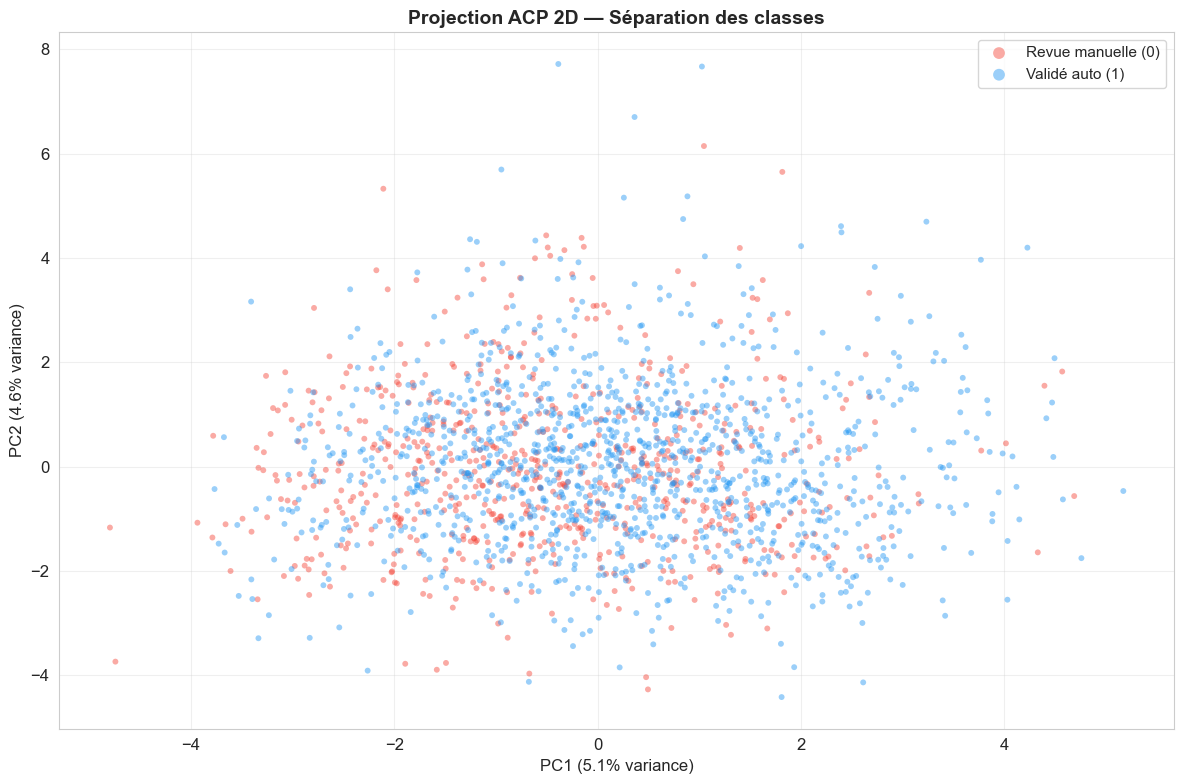

  PC1 explique 5.1% | PC2 explique 4.6% | Total = 9.7%


In [20]:
# ================================================================
# SECTION 6.3 — PROJECTION 2D (PC1 vs PC2)
# ================================================================
# On projette les données dans l'espace des 2 premières composantes
# principales pour visualiser la séparation entre les classes.
# Si les nuages de points sont bien séparés → les features encodent
# bien l'information discriminante entre validés et refusés.
# ================================================================

# ACP à 2 composantes pour la visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_pca_scaled)

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(12, 8))

for cls, color, label in [(0, COLOR_NEG, 'Revue manuelle (0)'),
                           (1, COLOR_POS, 'Validé auto (1)')]:
    mask = (y_pca == cls).values
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, alpha=0.45, s=18, edgecolors='none', label=label)

ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=12)
ax.set_title('Projection ACP 2D — Séparation des classes', fontweight='bold', fontsize=14)
ax.legend(markerscale=2, fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'  PC1 explique {var1:.1f}% | PC2 explique {var2:.1f}% | Total = {var1+var2:.1f}%')

---
## 7. Préparation Train/Test + Normalisation

In [21]:
# ================================================================
# SECTION 7 — SÉPARATION TRAIN / TEST ET NORMALISATION
# ================================================================
# On divise le dataset en :
#   - Train set (80%) : utilisé pour entraîner et optimiser les modèles
#   - Test set  (20%) : réservé pour l'évaluation finale (jamais vu)
#
# stratify=y : garantit que la distribution des classes est préservée
# dans les deux sets (important pour les datasets déséquilibrés).
#
# StandardScaler : normalise les features (µ=0, σ=1).
# ATTENTION : le scaler est FIT uniquement sur le train set,
# puis TRANSFORM appliqué sur les deux sets. Cela évite le
# "data leakage" (contamination du test par les stats du train).
# ================================================================

# --- Features et cible ---
X = df_encoded.drop(columns=['validation_status'])
y = df_encoded['validation_status'].astype(int)

# --- Split stratifié 80/20 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # préserver le ratio de classes
)

print(f'  X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'  Distribution train : {dict(y_train.value_counts())}')
print(f'  Distribution test  : {dict(y_test.value_counts())}')

# --- Normalisation (StandardScaler) ---
# Fit sur TRAIN uniquement → transform sur train ET test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\n  Après normalisation :')
print(f'    Moyenne train (5 premières)  : {X_train_scaled.mean(axis=0)[:5].round(4)}')
print(f'    Std train (5 premières)      : {X_train_scaled.std(axis=0)[:5].round(4)}')

# --- Cross-validation stratifiée (5 folds) ---
# Sera réutilisée pour comparer les modèles de manière fiable
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'\n  Cross-validation : {cv}')

  X_train : (1565, 52)  |  X_test : (392, 52)
  Distribution train : {1: 997, 0: 568}
  Distribution test  : {1: 250, 0: 142}

  Après normalisation :
    Moyenne train (5 premières)  : [ 0.  0. -0.  0. -0.]
    Std train (5 premières)      : [1. 1. 1. 1. 1.]

  Cross-validation : StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [22]:
# ================================================================
# HELPER FUNCTION — evaluate_model()
# ================================================================
# Fonction utilitaire réutilisée pour les 3 modèles supervisés.
# Elle calcule et affiche toutes les métriques clés :
#   - Accuracy  : % de prédictions correctes (toutes classes)
#   - Precision : parmi les validés prédits, combien l'étaient vraiment ?
#   - Recall    : parmi les vrais validés, combien détectés ?
#   - F1-Score  : moyenne harmonique Precision/Recall
#   - ROC-AUC   : aire sous la courbe ROC (capacité de discrimination)
# Elle retourne aussi les probabilités prédites pour la courbe ROC.
# ================================================================

def evaluate_model(model, X_test_s, y_test, model_name, X_train_s=None, y_train=None, cv=None):
    """
    Évalue un modèle entraîné et affiche ses métriques.
    
    Paramètres
    ----------
    model      : modèle sklearn entraîné
    X_test_s   : features test normalisées
    y_test     : labels test
    model_name : nom à afficher
    X_train_s  : features train (optionnel, pour cross-val)
    y_train    : labels train  (optionnel)
    cv         : objet KFold   (optionnel)
    
    Retourne
    --------
    dict avec toutes les métriques et les probabilités prédites
    """
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)
    
    # Cross-validation si données train fournies
    cv_mean = cv_std = None
    if X_train_s is not None and y_train is not None and cv is not None:
        cv_scores = cross_val_score(model, X_train_s, y_train,
                                    cv=cv, scoring='f1', n_jobs=-1)
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
    
    print(f'\n' + '='*55)
    print(f'  RÉSULTATS — {model_name.upper()}')
    print('='*55)
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    if cv_mean is not None:
        print(f'  CV F1 (5fold): {cv_mean:.4f} ± {cv_std:.4f}')
    print()
    print('  Rapport complet :')
    print(classification_report(y_test, y_pred,
                                target_names=['Revue manuelle', 'Validé auto']))
    
    return {'name': model_name, 'accuracy': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'auc': auc,
            'cv_f1': cv_mean, 'y_pred': y_pred, 'y_proba': y_proba}

# Dictionnaire global pour stocker les résultats de tous les modèles
all_results = {}
print('✅ Fonction evaluate_model() prête.')

✅ Fonction evaluate_model() prête.


---
## 8. Modèle 1 — Random Forest

In [23]:
# ================================================================
# SECTION 8.1 — RANDOM FOREST (MODÈLE DE BASE)
# ================================================================
# Le Random Forest est un ensemble de N arbres de décision entraînés
# chacun sur un sous-ensemble aléatoire des données et des features.
# La prédiction finale est un vote majoritaire (classification).
#
# Avantages :
#   - Robuste aux outliers et aux features non normalisées
#   - Fournit une importance des features (feature importances)
#   - class_weight='balanced' : compense le déséquilibre des classes
#     en augmentant le poids des exemples de la classe minoritaire
# ================================================================

print('Entraînement du Random Forest (base)...')

rf_base = RandomForestClassifier(
    n_estimators=100,         # 100 arbres dans la forêt
    class_weight='balanced',  # pondération inverse à la fréquence des classes
    random_state=42,
    n_jobs=-1                 # parallélisation sur tous les cœurs CPU
)
rf_base.fit(X_train_scaled, y_train)

# Évaluation complète
res_rf_base = evaluate_model(rf_base, X_test_scaled, y_test,
                              'Random Forest Base',
                              X_train_scaled, y_train, cv)
all_results['RF Base'] = res_rf_base

Entraînement du Random Forest (base)...

  RÉSULTATS — RANDOM FOREST BASE
  Accuracy  : 0.6760  (67.60%)
  Precision : 0.7128
  Recall    : 0.8240
  F1-Score  : 0.7644
  ROC-AUC   : 0.7355
  CV F1 (5fold): 0.7977 ± 0.0135

  Rapport complet :
                precision    recall  f1-score   support

Revue manuelle       0.57      0.42      0.48       142
   Validé auto       0.71      0.82      0.76       250

      accuracy                           0.68       392
     macro avg       0.64      0.62      0.62       392
  weighted avg       0.66      0.68      0.66       392



In [24]:
# ================================================================
# SECTION 8.2 — RANDOM FOREST OPTIMISÉ (GridSearchCV)
# ================================================================
# GridSearchCV teste toutes les combinaisons de l'espace de paramètres
# défini dans param_grid, avec validation croisée.
#
# Paramètres explorés :
#   n_estimators  : nombre d'arbres (plus = mieux jusqu'à un plateau)
#   max_depth     : profondeur maximale (évite le surapprentissage)
#   min_samples_split : nb min d'exemples pour splitter un nœud
#
# scoring='f1' : on optimise le F1-Score (équilibre Precision/Recall)
# ================================================================

print('GridSearchCV Random Forest (patience, ~1 min)...')

param_grid_rf = {
    'n_estimators' : [100, 200],          # 100 ou 200 arbres
    'max_depth'    : [None, 10, 20],       # profondeur libre ou limitée
    'min_samples_split': [2, 5],           # taille minimum pour splitter
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,              # StratifiedKFold 5 folds
    scoring='f1',       # métrique d'optimisation
    n_jobs=-1,          # parallélisation
    verbose=0
)
grid_rf.fit(X_train_scaled, y_train)

print(f'  Meilleurs paramètres : {grid_rf.best_params_}')
print(f'  Meilleur F1 CV       : {grid_rf.best_score_:.4f}')

rf_best = grid_rf.best_estimator_
res_rf_best = evaluate_model(rf_best, X_test_scaled, y_test,
                              'Random Forest Optimisé',
                              X_train_scaled, y_train, cv)
all_results['RF Optimisé'] = res_rf_best

GridSearchCV Random Forest (patience, ~1 min)...
  Meilleurs paramètres : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  Meilleur F1 CV       : 0.8087

  RÉSULTATS — RANDOM FOREST OPTIMISÉ
  Accuracy  : 0.6786  (67.86%)
  Precision : 0.7138
  Recall    : 0.8280
  F1-Score  : 0.7667
  ROC-AUC   : 0.7233
  CV F1 (5fold): 0.8087 ± 0.0114

  Rapport complet :
                precision    recall  f1-score   support

Revue manuelle       0.58      0.42      0.48       142
   Validé auto       0.71      0.83      0.77       250

      accuracy                           0.68       392
     macro avg       0.65      0.62      0.63       392
  weighted avg       0.66      0.68      0.66       392



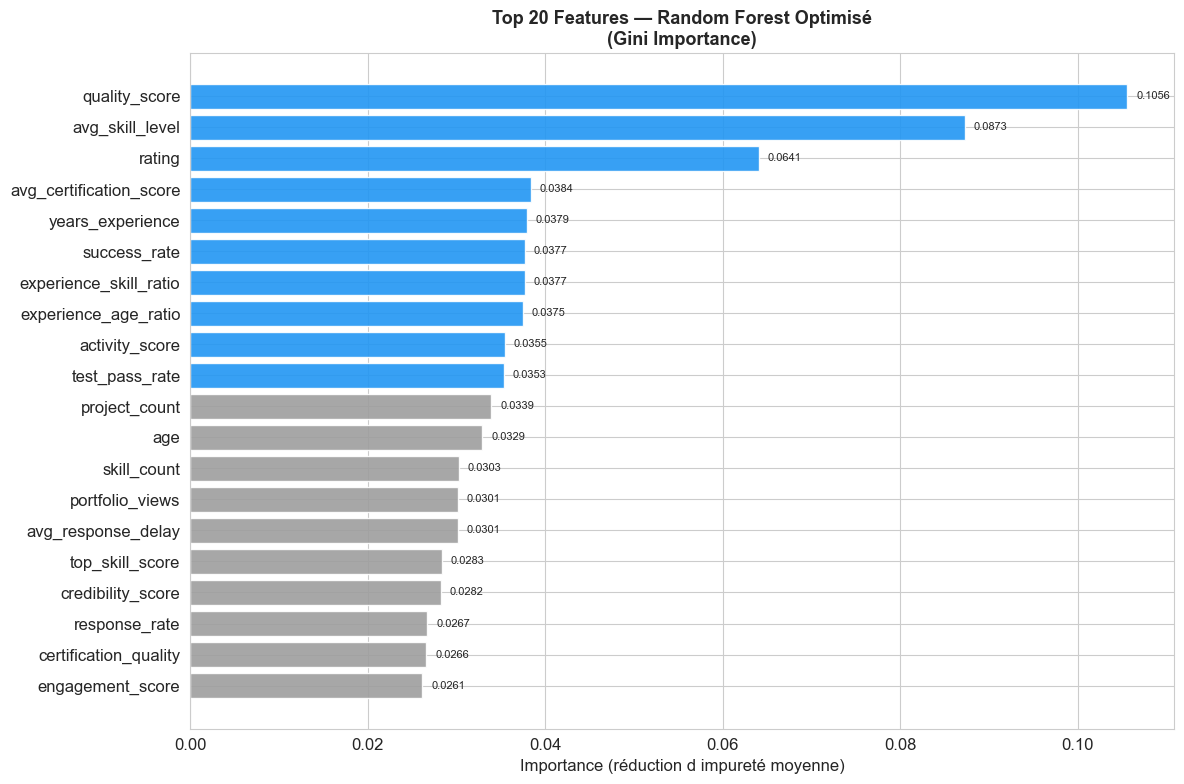

In [25]:
# ================================================================
# SECTION 8.3 — IMPORTANCE DES FEATURES (Random Forest)
# ================================================================
# Le Random Forest calcule l'importance de chaque feature basée sur
# la réduction d'impureté moyenne sur tous les arbres (Gini importance).
# Une feature importante est celle qui réduit le plus l'impureté
# (désordre) lors des splits de l'arbre.
#
# On affiche le Top 20 pour identifier les variables les plus
# discriminantes pour la décision de validation.
# ================================================================

# Récupérer les importances du modèle optimisé
importances = rf_best.feature_importances_
feat_names  = X_train.columns.tolist()

# Créer un DataFrame trié par importance décroissante
feat_imp_df = pd.DataFrame({
    'Feature'   : feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors_imp = [COLOR_POS if imp > feat_imp_df['Importance'].median() else COLOR_NEUT
              for imp in feat_imp_df['Importance']]
bars = ax.barh(feat_imp_df['Feature'][::-1], feat_imp_df['Importance'][::-1],
               color=colors_imp[::-1], edgecolor='white', alpha=0.9)
ax.set_title('Top 20 Features — Random Forest Optimisé\n(Gini Importance)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (réduction d impureté moyenne)')
# Annoter les valeurs
for bar, val in zip(bars, feat_imp_df['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 9. Modèle 2 — XGBoost

In [26]:
# ================================================================
# SECTION 9.1 — XGBOOST (MODÈLE DE BASE)
# ================================================================
# XGBoost (eXtreme Gradient Boosting) est un algorithme de boosting.
# Contrairement au Random Forest (arbres indépendants),
# XGBoost construit les arbres SÉQUENTIELLEMENT : chaque arbre
# corrige les erreurs du précédent en minimisant une fonction de perte.
#
# Avantages vs Random Forest :
#   + Souvent plus performant sur données tabulaires
#   + Régularisation L1/L2 intégrée (évite surapprentissage)
#   - Plus de hyperparamètres à régler
#   - Plus long à entraîner
#
# scale_pos_weight : équivalent de class_weight='balanced' pour XGBoost.
# Valeur = nb exemples classe 0 / nb exemples classe 1.
# ================================================================

# Calculer le ratio pour gérer le déséquilibre des classes
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos = n_neg / n_pos
print(f'scale_pos_weight calculé : {scale_pos:.2f}')

xgb_base = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos,   # compensation déséquilibre
    random_state=42,
    eval_metric='logloss',        # métrique interne d évaluation
    verbosity=0                   # silencieux
)
xgb_base.fit(X_train_scaled, y_train)

res_xgb_base = evaluate_model(xgb_base, X_test_scaled, y_test,
                               'XGBoost Base',
                               X_train_scaled, y_train, cv)
all_results['XGB Base'] = res_xgb_base

scale_pos_weight calculé : 0.57

  RÉSULTATS — XGBOOST BASE
  Accuracy  : 0.6684  (66.84%)
  Precision : 0.7362
  Recall    : 0.7480
  F1-Score  : 0.7421
  ROC-AUC   : 0.7339
  CV F1 (5fold): 0.7914 ± 0.0202

  Rapport complet :
                precision    recall  f1-score   support

Revue manuelle       0.54      0.53      0.54       142
   Validé auto       0.74      0.75      0.74       250

      accuracy                           0.67       392
     macro avg       0.64      0.64      0.64       392
  weighted avg       0.67      0.67      0.67       392



In [27]:
# ================================================================
# SECTION 9.2 — XGBOOST OPTIMISÉ (GridSearchCV)
# ================================================================
# Hyperparamètres clés de XGBoost :
#   max_depth       : profondeur des arbres (3-6 conseillé)
#   learning_rate   : taux d apprentissage (plus petit = plus stable)
#   n_estimators    : nombre d arbres (compensé par learning_rate)
#   subsample       : fraction des données utilisée par arbre (régul.)
# ================================================================

print('GridSearchCV XGBoost (patience, ~2 min)...')

param_grid_xgb = {
    'max_depth'     : [3, 5],          # profondeur des arbres
    'learning_rate' : [0.05, 0.1],     # pas d apprentissage
    'n_estimators'  : [100, 200],      # nombre d arbres
    'subsample'     : [0.8, 1.0],      # fraction des données par arbre
}

grid_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos, random_state=42,
                  eval_metric='logloss', verbosity=0),
    param_grid_xgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_xgb.fit(X_train_scaled, y_train)

print(f'  Meilleurs paramètres : {grid_xgb.best_params_}')
print(f'  Meilleur F1 CV       : {grid_xgb.best_score_:.4f}')

xgb_best = grid_xgb.best_estimator_
res_xgb_best = evaluate_model(xgb_best, X_test_scaled, y_test,
                               'XGBoost Optimisé',
                               X_train_scaled, y_train, cv)
all_results['XGB Optimisé'] = res_xgb_best

GridSearchCV XGBoost (patience, ~2 min)...
  Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
  Meilleur F1 CV       : 0.7994

  RÉSULTATS — XGBOOST OPTIMISÉ
  Accuracy  : 0.6939  (69.39%)
  Precision : 0.7731
  Recall    : 0.7360
  F1-Score  : 0.7541
  ROC-AUC   : 0.7506
  CV F1 (5fold): 0.7994 ± 0.0220

  Rapport complet :
                precision    recall  f1-score   support

Revue manuelle       0.57      0.62      0.59       142
   Validé auto       0.77      0.74      0.75       250

      accuracy                           0.69       392
     macro avg       0.67      0.68      0.67       392
  weighted avg       0.70      0.69      0.70       392



---
## 10. Modèle 3 — SVM (Support Vector Machine)

In [28]:
# ================================================================
# SECTION 10.1 — SVM (MODÈLE DE BASE)
# ================================================================
# Le SVM cherche l'hyperplan de séparation OPTIMAL (max marge)
# entre les deux classes dans l'espace des features.
#
# kernel='rbf' : Radial Basis Function — projette les données
# dans un espace de dimension supérieure pour séparer des classes
# non linéairement séparables dans l'espace d'origine.
#
# C : paramètre de régularisation (plus grand = moins régularisé,
#     permet des violations de marge plus petites).
# probability=True : active le calcul des probabilités (nécessaire
# pour ROC-AUC), mais ralentit légèrement l'entraînement.
# ================================================================

print('Entraînement du SVM (peut prendre quelques secondes)...')

svm_base = SVC(
    kernel='rbf',           # noyau gaussien (adapté aux données non linéaires)
    C=1.0,                  # régularisation (défaut)
    class_weight='balanced',# compenser le déséquilibre des classes
    probability=True,       # activer predict_proba (pour ROC-AUC)
    random_state=42
)
svm_base.fit(X_train_scaled, y_train)

res_svm_base = evaluate_model(svm_base, X_test_scaled, y_test,
                               'SVM Base',
                               X_train_scaled, y_train, cv)
all_results['SVM Base'] = res_svm_base

Entraînement du SVM (peut prendre quelques secondes)...

  RÉSULTATS — SVM BASE
  Accuracy  : 0.6556  (65.56%)
  Precision : 0.7674
  Recall    : 0.6600
  F1-Score  : 0.7097
  ROC-AUC   : 0.6787
  CV F1 (5fold): 0.7354 ± 0.0283

  Rapport complet :
                precision    recall  f1-score   support

Revue manuelle       0.52      0.65      0.58       142
   Validé auto       0.77      0.66      0.71       250

      accuracy                           0.66       392
     macro avg       0.64      0.65      0.64       392
  weighted avg       0.68      0.66      0.66       392



In [29]:
# ================================================================
# SECTION 10.2 — SVM OPTIMISÉ (GridSearchCV)
# ================================================================
# Hyperparamètres clés du SVM RBF :
#   C     : contrôle le trade-off bias-variance
#           C élevé → faible biais, variance élevée (surapprentissage)
#           C faible → fort biais, faible variance (sous-apprentissage)
#   gamma : contrôle la portée d influence d un point d entraînement
#           gamma élevé → modèle complexe (risque surapprentissage)
#           gamma faible → modèle plus doux
# ================================================================

print('GridSearchCV SVM (peut prendre plusieurs minutes)...')

param_grid_svm = {
    'C'     : [0.1, 1, 10],              # régularisation
    'gamma' : ['scale', 'auto', 0.01],   # portée du noyau RBF
}

grid_svm = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced',
        probability=True, random_state=42),
    param_grid_svm,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_svm.fit(X_train_scaled, y_train)

print(f'  Meilleurs paramètres : {grid_svm.best_params_}')
print(f'  Meilleur F1 CV       : {grid_svm.best_score_:.4f}')

svm_best = grid_svm.best_estimator_
res_svm_best = evaluate_model(svm_best, X_test_scaled, y_test,
                               'SVM Optimisé',
                               X_train_scaled, y_train, cv)
all_results['SVM Optimisé'] = res_svm_best

GridSearchCV SVM (peut prendre plusieurs minutes)...
  Meilleurs paramètres : {'C': 1, 'gamma': 'scale'}
  Meilleur F1 CV       : 0.7354

  RÉSULTATS — SVM OPTIMISÉ
  Accuracy  : 0.6556  (65.56%)
  Precision : 0.7674
  Recall    : 0.6600
  F1-Score  : 0.7097
  ROC-AUC   : 0.6787
  CV F1 (5fold): 0.7354 ± 0.0283

  Rapport complet :
                precision    recall  f1-score   support

Revue manuelle       0.52      0.65      0.58       142
   Validé auto       0.77      0.66      0.71       250

      accuracy                           0.66       392
     macro avg       0.64      0.65      0.64       392
  weighted avg       0.68      0.66      0.66       392



---
## 11. Comparaison des Modèles Supervisés

In [30]:
# ================================================================
# SECTION 11.1 — TABLEAU COMPARATIF DES MÉTRIQUES
# ================================================================
# On compare les 6 variantes de modèles (base + optimisé × 3 algos)
# selon 5 métriques :
#   Accuracy  : performance globale
#   Precision : qualité des positifs prédits (évite faux positifs)
#   Recall    : sensibilité (évite faux négatifs)
#   F1-Score  : équilibre Precision/Recall
#   ROC-AUC   : discrimination globale (indépendant du seuil)
# ================================================================

# Construire le tableau comparatif
results_table = []
for name, res in all_results.items():
    results_table.append({
        'Modèle'   : name,
        'Accuracy' : round(res['accuracy'],  4),
        'Precision': round(res['precision'], 4),
        'Recall'   : round(res['recall'],    4),
        'F1-Score' : round(res['f1'],        4),
        'ROC-AUC'  : round(res['auc'],       4),
    })

df_results = pd.DataFrame(results_table).sort_values('F1-Score', ascending=False)
df_results.index = range(1, len(df_results) + 1)

print('COMPARAISON DES MODÈLES SUPERVISÉS')
print('='*75)
print(df_results.to_string())
print()
best_model_name = df_results.iloc[0]['Modèle']
print(f'  🏆 Meilleur modèle (F1) : {best_model_name}')
print(f'     F1-Score = {df_results.iloc[0]["F1-Score"]:.4f}')
print(f'     ROC-AUC  = {df_results.iloc[0]["ROC-AUC"]:.4f}')

COMPARAISON DES MODÈLES SUPERVISÉS
         Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1   RF Optimisé    0.6786     0.7138   0.828    0.7667   0.7233
2       RF Base    0.6760     0.7128   0.824    0.7644   0.7355
3  XGB Optimisé    0.6939     0.7731   0.736    0.7541   0.7506
4      XGB Base    0.6684     0.7362   0.748    0.7421   0.7339
5      SVM Base    0.6556     0.7674   0.660    0.7097   0.6787
6  SVM Optimisé    0.6556     0.7674   0.660    0.7097   0.6787

  🏆 Meilleur modèle (F1) : RF Optimisé
     F1-Score = 0.7667
     ROC-AUC  = 0.7233


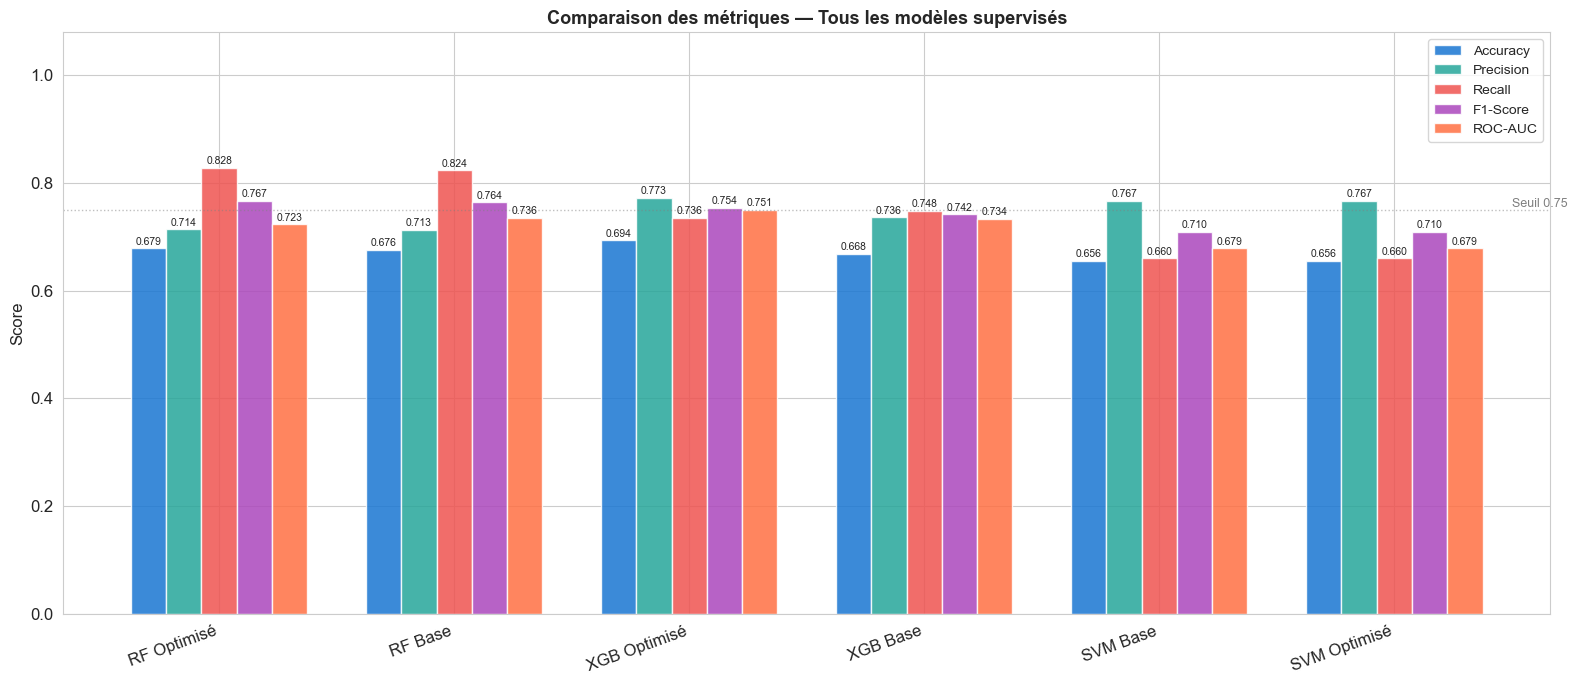

In [31]:
# ================================================================
# SECTION 11.2 — VISUALISATION COMPARATIVE DES MÉTRIQUES
# ================================================================
# Barplot groupé montrant les 4 métriques principales pour chaque modèle.
# Permet d'identifier rapidement les forces et faiblesses de chacun.
# ================================================================

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
n_models  = len(df_results)
n_metrics = len(metrics_to_plot)
x = np.arange(n_models)
width = 0.15
colors_bar = ['#1976D2', '#26A69A', '#EF5350', '#AB47BC', '#FF7043']

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_bar)):
    vals = df_results[metric].values
    bars = ax.bar(x + i*width, vals, width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    # Annoter les barres
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_results['Modèle'], rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title('Comparaison des métriques — Tous les modèles supervisés',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.axhline(y=0.75, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(n_models - 0.2, 0.755, 'Seuil 0.75', fontsize=9, color='gray')
plt.tight_layout()
plt.show()

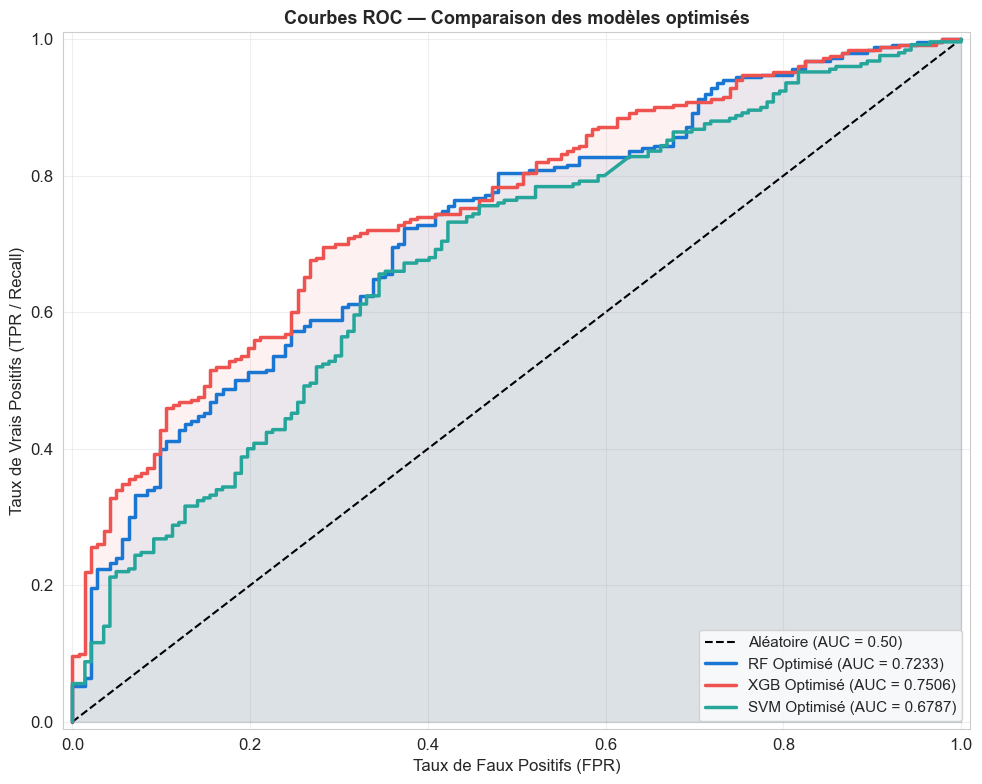

In [32]:
# ================================================================
# SECTION 11.3 — COURBES ROC
# ================================================================
# La courbe ROC (Receiver Operating Characteristic) trace :
#   - Axe X : Taux de faux positifs (FPR) = FP / (FP + TN)
#   - Axe Y : Taux de vrais positifs (TPR) = TP / (TP + FN)
#
# L'aire sous la courbe (AUC) résume la performance globale :
#   - AUC = 1.0 → modèle parfait
#   - AUC = 0.5 → modèle aléatoire (diagonale)
#
# On trace les courbes pour les 3 meilleurs modèles (versions optimisées).
# ================================================================

best_models = {
    'RF Optimisé' : all_results.get('RF Optimisé'),
    'XGB Optimisé': all_results.get('XGB Optimisé'),
    'SVM Optimisé': all_results.get('SVM Optimisé'),
}

roc_colors = {'RF Optimisé': '#1976D2', 'XGB Optimisé': '#EF5350', 'SVM Optimisé': '#26A69A'}

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Aléatoire (AUC = 0.50)')

for name, res in best_models.items():
    if res is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc_val = res['auc']
    ax.plot(fpr, tpr, linewidth=2.5,
            color=roc_colors[name],
            label=f'{name} (AUC = {auc_val:.4f})')
    ax.fill_between(fpr, tpr, alpha=0.08, color=roc_colors[name])

ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR / Recall)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles optimisés', fontweight='bold', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.show()

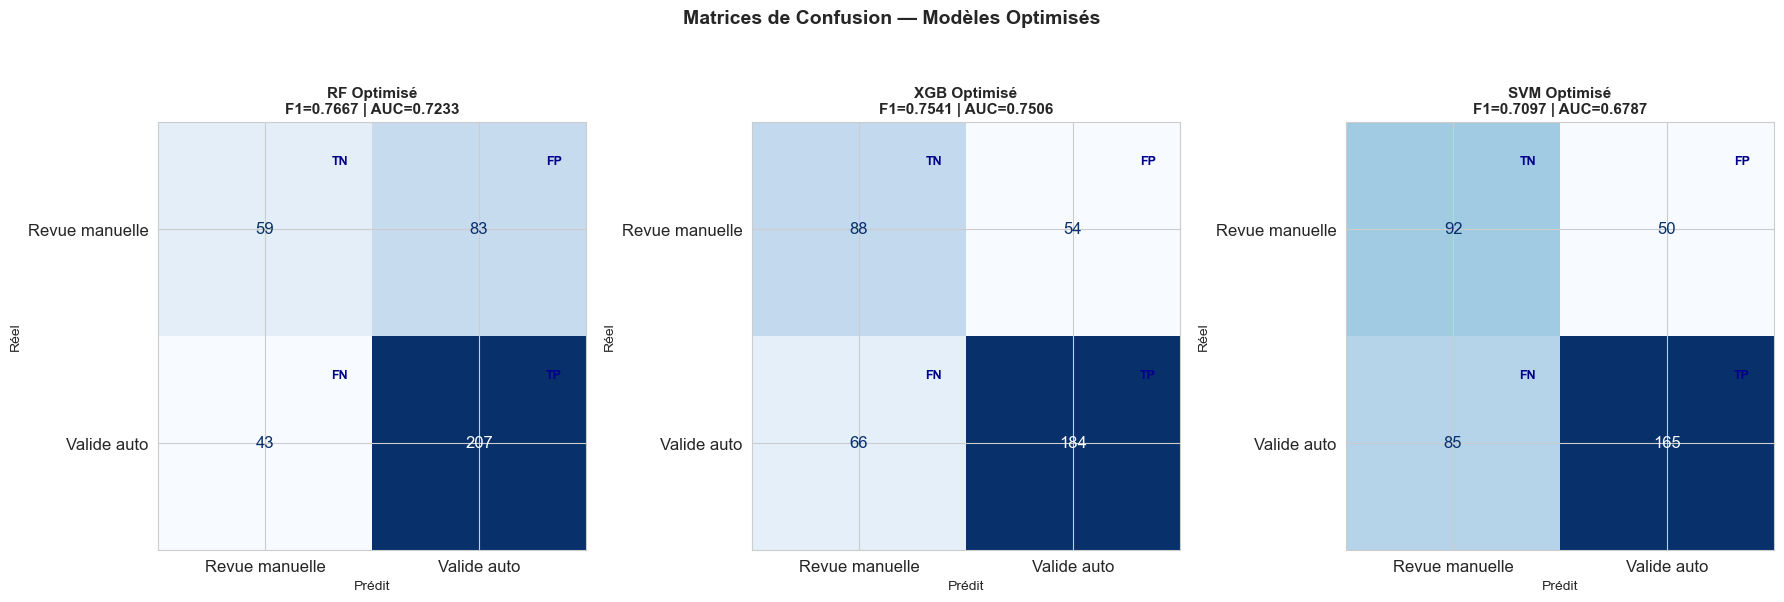

In [33]:
# ================================================================
# SECTION 11.4 — MATRICES DE CONFUSION
# ================================================================
# La matrice de confusion décompose les prédictions en 4 cases :
#   TN (Vrai Négatif) : prédit 0, réel 0 → envoyé en revue, était bien à revoir
#   FP (Faux Positif) : prédit 1, réel 0 → validé à tort (risque métier élevé!)
#   FN (Faux Négatif) : prédit 0, réel 1 → refusé à tort (perte de talent)
#   TP (Vrai Positif) : prédit 1, réel 1 → validé correctement
#
# Dans notre contexte, les FP sont critiques : valider un mauvais profil
# est plus coûteux que de refuser un bon profil.
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, res) in zip(axes, best_models.items()):
    if res is None:
        ax.set_visible(False)
        continue
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm,
                                  display_labels=['Revue manuelle', 'Valide auto'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nF1={res["f1"]:.4f} | AUC={res["auc"]:.4f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Prédit', fontsize=10)
    ax.set_ylabel('Réel', fontsize=10)
    # Annoter TN/FP/FN/TP
    labels_pos = ['TN', 'FP', 'FN', 'TP']
    for idx, (i, j) in enumerate([(0,0),(0,1),(1,0),(1,1)]):
        ax.text(j + 0.35, i - 0.3, labels_pos[idx], fontsize=9,
                ha='center', color='darkblue', fontweight='bold')

plt.suptitle('Matrices de Confusion — Modèles Optimisés',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Score de Qualité Composite — Règle Métier à 3 Niveaux

In [34]:
# ================================================================
# SECTION 12 — SCORE DE QUALITÉ ET DÉCISION À 3 NIVEAUX
# ================================================================
# Le score de qualité (déjà créé en feature engineering) est ici
# utilisé comme RÈGLE DE DÉCISION MÉTIER transparente :
#
#   Score ≥ 70  → Validation automatique directe (profil excellent)
#   40 ≤ Score < 70 → Revue manuelle recommandée (profil à examiner)
#   Score < 40  → Rejet automatique (profil insuffisant)
#
# Cette approche complémentaire aux modèles ML offre :
#   - Transparence (décision explicable aux RH)
#   - Contrôle humain pour les cas ambigus
#   - Réduction de la charge de travail de validation
# ================================================================

quality_scores = df['quality_score'].values
val_status     = df['validation_status'].values

# Classifier selon les seuils métier
decisions = np.where(quality_scores >= 70, 'Validation auto',
            np.where(quality_scores >= 40, 'Revue manuelle', 'Rejet auto'))

df_qual = df.copy()
df_qual['decision_metier'] = decisions

# Statistiques
print('DISTRIBUTION DES DÉCISIONS MÉTIER (Score de Qualité)')
print('='*60)
for dec in ['Validation auto', 'Revue manuelle', 'Rejet auto']:
    n = (decisions == dec).sum()
    pct = n / len(decisions) * 100
    # Taux de vrais validés dans chaque catégorie
    mask = decisions == dec
    taux_val = val_status[mask].mean() * 100 if mask.sum() > 0 else 0
    print(f'  {dec:20s}: {n:4d} ({pct:.1f}%) | taux réels validés = {taux_val:.1f}%')

print(f'\n  Score moyen  : {quality_scores.mean():.2f}')
print(f'  Score médian : {np.median(quality_scores):.2f}')
print(f'  Score min    : {quality_scores.min():.2f}')
print(f'  Score max    : {quality_scores.max():.2f}')

DISTRIBUTION DES DÉCISIONS MÉTIER (Score de Qualité)
  Validation auto     :   33 (1.7%) | taux réels validés = 97.0%
  Revue manuelle      : 1760 (89.9%) | taux réels validés = 65.4%
  Rejet auto          :  164 (8.4%) | taux réels validés = 39.0%

  Score moyen  : 52.29
  Score médian : 52.22
  Score min    : 25.38
  Score max    : 82.80


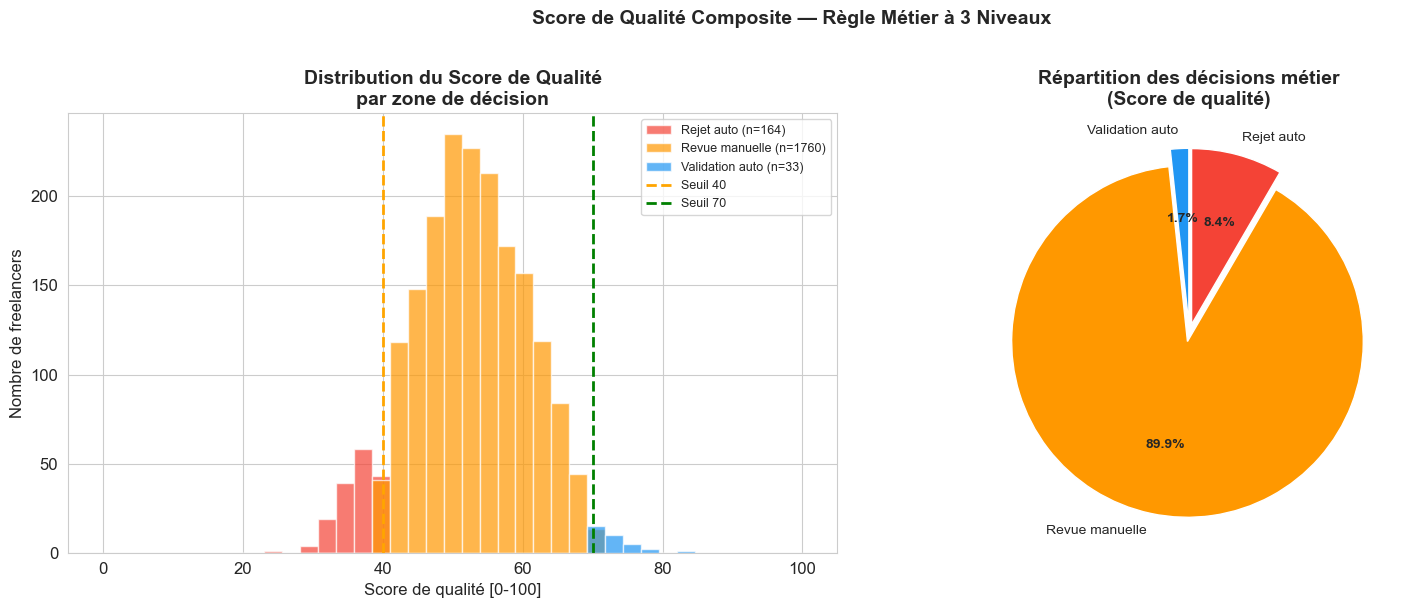

In [35]:
# ================================================================
# SECTION 12.2 — VISUALISATION DU SCORE DE QUALITÉ
# ================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Distribution du score avec zones colorées ---
colors_map = {'Rejet auto': COLOR_NEG, 'Revue manuelle': '#FF9800', 'Validation auto': COLOR_POS}
# Histogramme coloré par zone
bins = np.linspace(0, 100, 40)
for dec, color in colors_map.items():
    mask = decisions == dec
    if mask.sum() > 0:
        ax1.hist(quality_scores[mask], bins=bins, color=color,
                 alpha=0.7, label=f'{dec} (n={mask.sum()})', edgecolor='white')

ax1.axvline(40, color='orange', linestyle='--', linewidth=2, label='Seuil 40')
ax1.axvline(70, color='green',  linestyle='--', linewidth=2, label='Seuil 70')
ax1.set_title('Distribution du Score de Qualité\npar zone de décision',
              fontweight='bold')
ax1.set_xlabel('Score de qualité [0-100]')
ax1.set_ylabel('Nombre de freelancers')
ax1.legend(fontsize=9)

# --- Pie chart des décisions ---
dec_counts = {d: (decisions == d).sum() for d in ['Validation auto', 'Revue manuelle', 'Rejet auto']}
pie_colors = [COLOR_POS, '#FF9800', COLOR_NEG]
explode = (0.05, 0.05, 0.05)
wedges, texts, autotexts = ax2.pie(
    dec_counts.values(),
    labels=dec_counts.keys(),
    autopct='%1.1f%%',
    colors=pie_colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax2.set_title('Répartition des décisions métier\n(Score de qualité)',
              fontweight='bold')

plt.suptitle('Score de Qualité Composite — Règle Métier à 3 Niveaux',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 13. Clustering Non Supervisé — K-Means

In [36]:
# ================================================================
# SECTION 13.1 — PRÉPARATION DES DONNÉES POUR LE CLUSTERING
# ================================================================
# L'apprentissage non supervisé ne connaît pas les labels.
# Il cherche des groupes naturels (clusters) dans les données.
#
# On utilise un sous-ensemble de features pertinentes pour le
# profil freelancer (pas toutes les colonnes encodées one-hot).
# On standardise les données car K-Means est basé sur la distance
# euclidienne (sensible aux échelles).
# ================================================================

# Features sélectionnées pour le clustering
cluster_features = [
    'age', 'years_experience', 'skill_count', 'avg_skill_level',
    'project_count', 'rating', 'success_rate', 'certification_count',
    'response_rate', 'endorsement_count', 'avg_certification_score',
    'test_pass_rate', 'quality_score', 'profile_completeness',
    'credibility_score', 'activity_score'
]

X_cluster = df[cluster_features].copy()
scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

# Réduction 2D pour la visualisation (ACP)
pca_clust = PCA(n_components=2, random_state=42)
X_cluster_2d = pca_clust.fit_transform(X_cluster_scaled)

print(f'  Features pour clustering : {len(cluster_features)}')
print(f'  Variance expliquée 2D    : {pca_clust.explained_variance_ratio_.sum()*100:.1f}%')

  Features pour clustering : 16
  Variance expliquée 2D    : 25.2%


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  K=2 → Inertie=28575 | Silhouette=0.0831
  K=3 → Inertie=26673 | Silhouette=0.0825
  K=4 → Inertie=25325 | Silhouette=0.0756
  K=5 → Inertie=24485 | Silhouette=0.0669
  K=6 → Inertie=23927 | Silhouette=0.0641
  K=7 → Inertie=23471 | Silhouette=0.0622
  K=8 → Inertie=23025 | Silhouette=0.0622
  K=9 → Inertie=22641 | Silhouette=0.0610
  K=10 → Inertie=22304 | Silhouette=0.0608


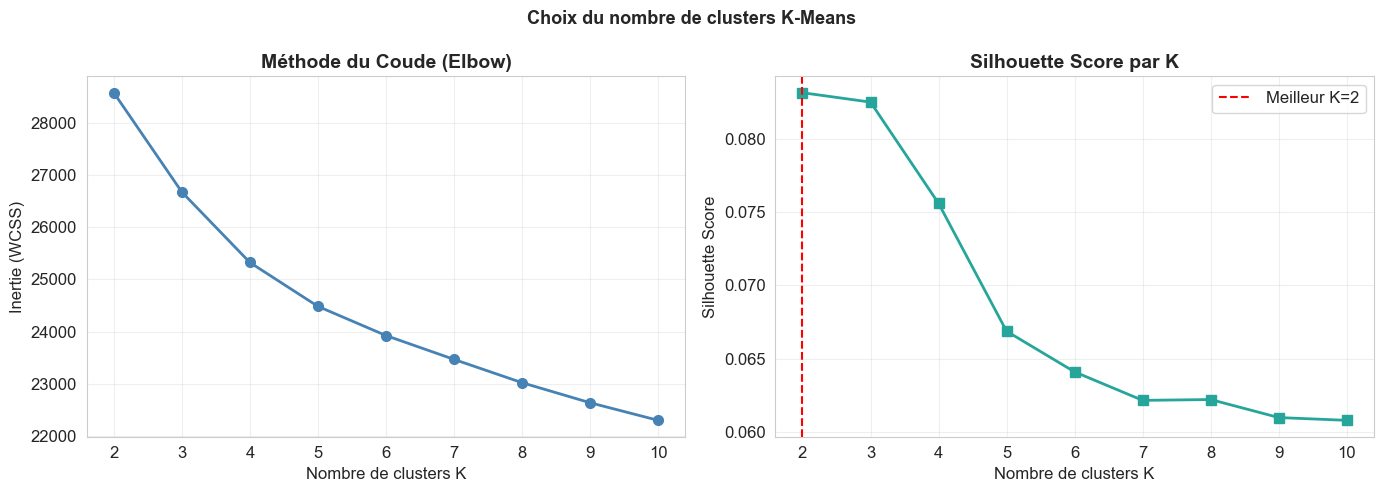


  → K optimal sélectionné : 2


In [37]:
# ================================================================
# SECTION 13.2 — MÉTHODE DU COUDE (ELBOW) POUR CHOISIR K
# ================================================================
# La méthode du coude (elbow method) consiste à tracer l'inertie
# (somme des distances intra-cluster) en fonction de K.
# L'inertie diminue toujours quand K augmente, mais à partir
# d'un certain K, le gain devient marginal → c'est le "coude".
#
# On trace aussi le Silhouette Score :
# mesure la compacité et la séparation des clusters.
# Score proche de +1 → clusters denses et bien séparés.
# ================================================================

inertias     = []
silhouettes  = []
k_range      = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster_scaled, labels)
    silhouettes.append(sil)
    print(f'  K={k} → Inertie={km.inertia_:.0f} | Silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Courbe du coude
ax1.plot(list(k_range), inertias, 'o-', color='steelblue',
         markersize=7, linewidth=2)
ax1.set_title('Méthode du Coude (Elbow)', fontweight='bold')
ax1.set_xlabel('Nombre de clusters K')
ax1.set_ylabel('Inertie (WCSS)')
ax1.grid(True, alpha=0.3)

# Silhouette Score
ax2.plot(list(k_range), silhouettes, 's-', color='#26A69A',
         markersize=7, linewidth=2)
best_k_sil = k_range.start + np.argmax(silhouettes)
ax2.axvline(best_k_sil, color='red', linestyle='--', linewidth=1.5,
            label=f'Meilleur K={best_k_sil}')
ax2.set_title('Silhouette Score par K', fontweight='bold')
ax2.set_xlabel('Nombre de clusters K')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Choix du nombre de clusters K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = best_k_sil
print(f'\n  → K optimal sélectionné : {best_k}')

In [38]:
# ================================================================
# SECTION 13.3 — K-MEANS FINAL + ANALYSE DES CLUSTERS
# ================================================================
# On entraîne le K-Means avec le K optimal et on analyse les profils
# des clusters : qui sont les freelancers dans chaque groupe ?
# Le taux de validation par cluster révèle si certains groupes
# correspondent aux profils "validables" vs "à risque".
# ================================================================

# K-Means final avec le meilleur K
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels_km = km_final.fit_predict(X_cluster_scaled)

sil_final = silhouette_score(X_cluster_scaled, cluster_labels_km)
print(f'K-Means (K={best_k}) — Silhouette Score final : {sil_final:.4f}')

# Ajouter les labels au dataframe
df_km = df.copy()
df_km['cluster_km'] = cluster_labels_km

# --- Profils des clusters ---
print('\n' + '='*65)
print('PROFILS DES CLUSTERS K-MEANS')
print('='*65)

profils = []
for c in range(best_k):
    subset = df_km[df_km['cluster_km'] == c]
    n = len(subset)
    taux_val = subset['validation_status'].mean() * 100
    profil = {
        'Cluster'       : c,
        'Taille'        : n,
        '% total'       : round(n / len(df_km) * 100, 1),
        'Taux valid.'   : round(taux_val, 1),
        'Rating moy.'   : round(subset['rating'].mean(), 2),
        'Exp. moy. (ans)': round(subset['years_experience'].mean(), 1),
        'Skills moy.'   : round(subset['skill_count'].mean(), 1),
        'Quality score' : round(subset['quality_score'].mean(), 1),
    }
    profils.append(profil)
    print(f'\n  Cluster {c} ({n} freelancers, {n/len(df_km)*100:.1f}%) :')
    for k_p, v_p in profil.items():
        if k_p not in ['Cluster', 'Taille']:
            print(f'    {k_p:20s}: {v_p}')

df_profils = pd.DataFrame(profils)

K-Means (K=2) — Silhouette Score final : 0.0831

PROFILS DES CLUSTERS K-MEANS

  Cluster 0 (977 freelancers, 49.9%) :
    % total             : 49.9
    Taux valid.         : 68.1
    Rating moy.         : 2.56
    Exp. moy. (ans)     : 15.0
    Skills moy.         : 5.9
    Quality score       : 53.3

  Cluster 1 (980 freelancers, 50.1%) :
    % total             : 50.1
    Taux valid.         : 59.4
    Rating moy.         : 2.43
    Exp. moy. (ans)     : 15.4
    Skills moy.         : 6.0
    Quality score       : 51.2


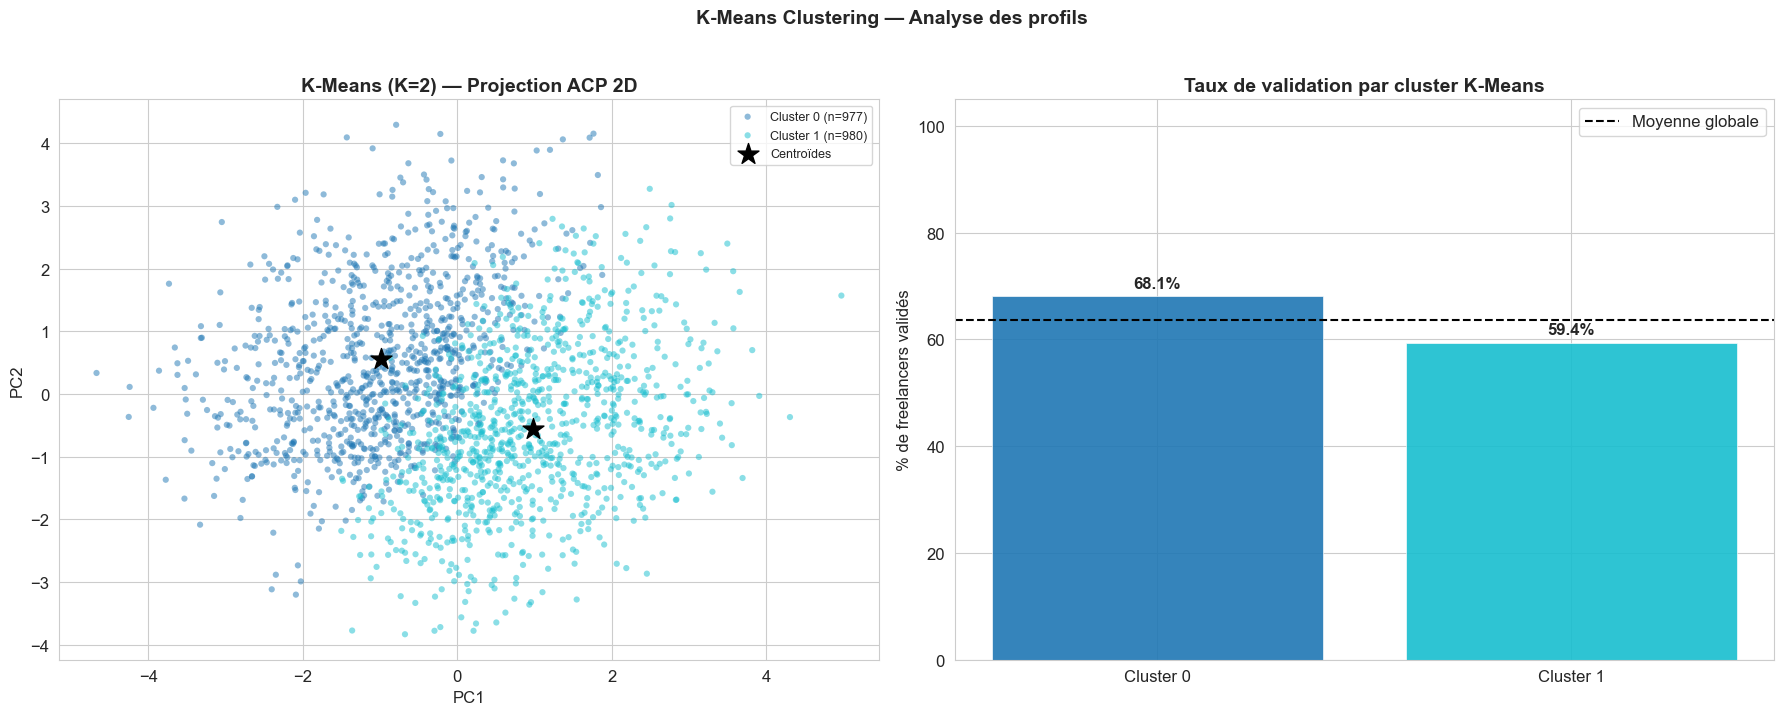

In [39]:
# ================================================================
# SECTION 13.4 — VISUALISATION K-MEANS (PROJECTION ACP 2D)
# ================================================================
# On projette les clusters dans l'espace ACP 2D pour visualiser
# la séparation spatiale des groupes.
# Les centroïdes (centres de clusters) sont marqués d'une étoile.
# ================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- Clusters K-Means ---
palette = plt.cm.tab10(np.linspace(0, 0.9, best_k))
for c in range(best_k):
    mask = cluster_labels_km == c
    ax1.scatter(X_cluster_2d[mask, 0], X_cluster_2d[mask, 1],
                c=[palette[c]], alpha=0.5, s=20, edgecolors='none',
                label=f'Cluster {c} (n={mask.sum()})')

# Centroïdes projetés en 2D
centroids_2d = pca_clust.transform(km_final.cluster_centers_)
ax1.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='*', s=250, zorder=5, label='Centroïdes')
ax1.set_title(f'K-Means (K={best_k}) — Projection ACP 2D', fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(fontsize=9)

# --- Taux de validation par cluster ---
colors_bar2 = [palette[i] for i in range(best_k)]
bars = ax2.bar([f'Cluster {c}' for c in range(best_k)],
               df_profils['Taux valid.'],
               color=colors_bar2, edgecolor='white', alpha=0.9, linewidth=0.5)
ax2.axhline(df['validation_status'].mean()*100, color='black',
            linestyle='--', linewidth=1.5, label='Moyenne globale')
ax2.set_title('Taux de validation par cluster K-Means', fontweight='bold')
ax2.set_ylabel('% de freelancers validés')
ax2.set_ylim(0, 105)
ax2.legend()
for bar, val in zip(bars, df_profils['Taux valid.']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('K-Means Clustering — Analyse des profils',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 14. Clustering Densité — DBSCAN

Méthode k-distance pour choisir eps (DBSCAN)...


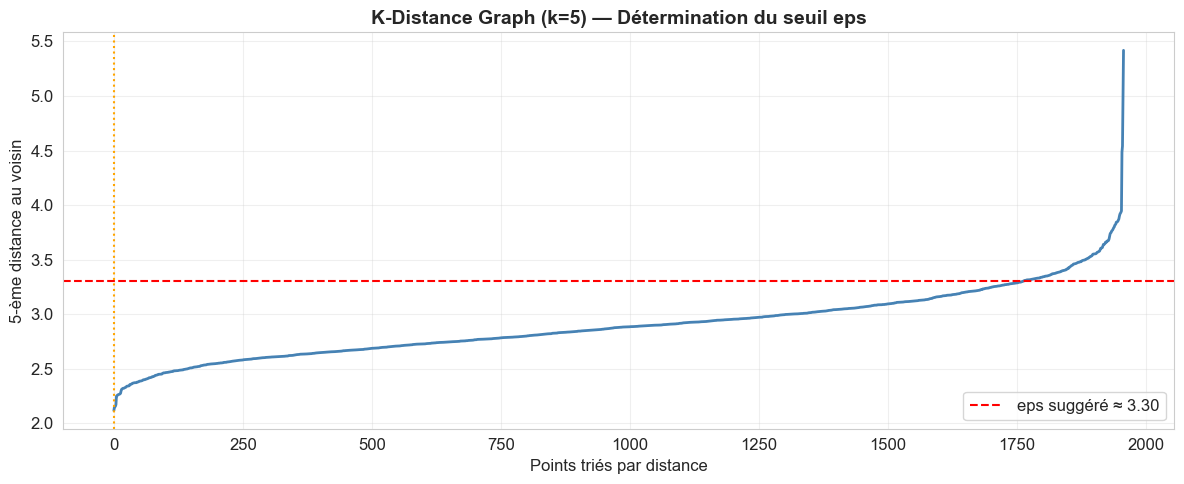

  eps suggéré par le coude : 3.30


In [40]:
# ================================================================
# SECTION 14.1 — DBSCAN : PRINCIPE ET PARAMÈTRES
# ================================================================
# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
# identifie des clusters comme des zones de HAUTE DENSITÉ séparées
# par des zones de basse densité.
#
# Avantages vs K-Means :
#   + Pas besoin de spécifier K à l'avance
#   + Détecte des clusters de formes arbitraires
#   + Identifie les OUTLIERS (points de bruit, label = -1)
#
# Paramètres clés :
#   eps        : rayon du voisinage (distance maximale entre 2 points
#                d'un même cluster)
#   min_samples: nombre minimum de voisins dans eps pour être un
#                "core point" (point central)
#
# Méthode k-distance pour choisir eps :
# On trie les distances au k-ème voisin le plus proche.
# Le "coude" dans cette courbe donne un bon eps.
# ================================================================

print('Méthode k-distance pour choisir eps (DBSCAN)...')

k_nn = 5   # nombre de voisins à examiner (= min_samples suggéré)
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_cluster_scaled)
distances, _ = nn.kneighbors(X_cluster_scaled)
dist_sorted   = np.sort(distances[:, k_nn-1])  # distances au k-ème voisin

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dist_sorted, linewidth=2, color='steelblue')
# Approximation du coude par gradient
gradient  = np.gradient(dist_sorted)
knee_idx  = np.argmax(gradient > gradient.mean() + gradient.std())
eps_suggested = dist_sorted[knee_idx] if knee_idx > 0 else dist_sorted[int(len(dist_sorted)*0.9)]
ax.axhline(eps_suggested, color='red', linestyle='--', linewidth=1.5,
           label=f'eps suggéré ≈ {eps_suggested:.2f}')
ax.axvline(knee_idx, color='orange', linestyle=':', linewidth=1.5)
ax.set_title(f'K-Distance Graph (k={k_nn}) — Détermination du seuil eps',
             fontweight='bold')
ax.set_xlabel('Points triés par distance')
ax.set_ylabel(f'{k_nn}-ème distance au voisin')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'  eps suggéré par le coude : {eps_suggested:.2f}')

In [41]:
# ================================================================
# SECTION 14.2 — RECHERCHE DES MEILLEURS PARAMÈTRES DBSCAN
# ================================================================
# On teste une grille de (eps, min_samples) et on mesure le
# Silhouette Score pour chaque combinaison.
# On évite les configurations produisant 0 ou 1 cluster
# (pas de silhouette calculable) ou trop de bruit (>50%).
# ================================================================

print('Grille de recherche DBSCAN (eps × min_samples)...')

eps_values   = np.arange(1.0, 5.0, 0.5)
min_s_values = [3, 5, 10]

results_dbscan = []
for eps in eps_values:
    for min_s in min_s_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        lbl = db.fit_predict(X_cluster_scaled)
        n_c  = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = (lbl == -1).sum()
        noise_pct = n_noise / len(lbl) * 100
        if n_c >= 2 and noise_pct < 50:
            sil = silhouette_score(X_cluster_scaled, lbl)
        else:
            sil = -1
        results_dbscan.append({
            'eps': round(eps, 1), 'min_samples': min_s,
            'n_clusters': n_c, 'n_noise': n_noise,
            'noise_pct': round(noise_pct, 1),
            'silhouette': round(sil, 4)
        })

df_dbscan_res = pd.DataFrame(results_dbscan)
print(df_dbscan_res.sort_values('silhouette', ascending=False).head(10).to_string(index=False))

# Sélectionner la meilleure config
valid = df_dbscan_res[df_dbscan_res['silhouette'] > -1]
if len(valid) > 0:
    best_db = valid.loc[valid['silhouette'].idxmax()]
else:
    best_db = pd.Series({'eps': 2.5, 'min_samples': 5, 'n_clusters': 2,
                         'n_noise': 0, 'noise_pct': 0, 'silhouette': -1})

print(f'\n  Meilleure config : eps={best_db["eps"]}, min_samples={int(best_db["min_samples"])}')
print(f'    Clusters = {int(best_db["n_clusters"])}, Bruit = {int(best_db["n_noise"])} ({best_db["noise_pct"]}%)')
print(f'    Silhouette = {best_db["silhouette"]}')

Grille de recherche DBSCAN (eps × min_samples)...
 eps  min_samples  n_clusters  n_noise  noise_pct  silhouette
 3.0            3           4      130        6.6      0.0338
 1.0            5           0     1957      100.0     -1.0000
 4.5            5           1        1        0.1     -1.0000
 4.5            3           1        1        0.1     -1.0000
 4.0           10           1        4        0.2     -1.0000
 4.0            5           1        3        0.2     -1.0000
 4.0            3           1        3        0.2     -1.0000
 3.5           10           1       14        0.7     -1.0000
 3.5            5           1       10        0.5     -1.0000
 3.5            3           1        8        0.4     -1.0000

  Meilleure config : eps=3.0, min_samples=3
    Clusters = 4, Bruit = 130 (6.6%)
    Silhouette = 0.0338


DBSCAN final (eps=3.0, min_samples=3)
  Nombre de clusters : 4
  Points de bruit    : 130 (6.6%)
  Silhouette Score   : 0.0338

  Profil moyen des outliers DBSCAN (points de bruit) :
    Rating moyen        : 2.44
    Expérience moyenne  : 14.7 ans
    Quality score moyen : 52.5
    Taux de validation  : 60.8%


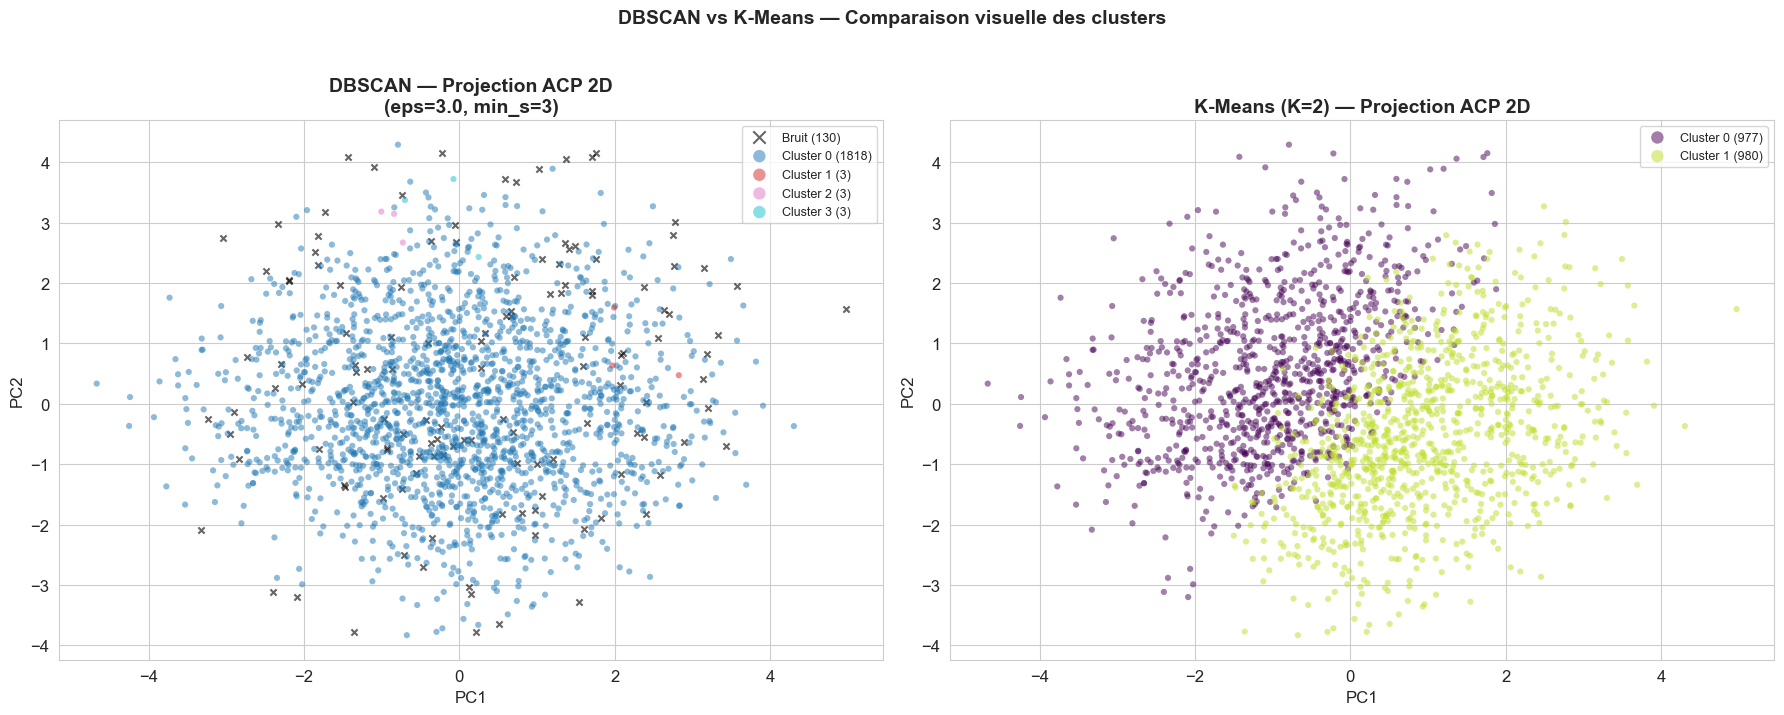

In [42]:
# ================================================================
# SECTION 14.3 — DBSCAN FINAL + VISUALISATION
# ================================================================
# On applique DBSCAN avec les paramètres optimaux et on compare
# visuellement avec K-Means.
# Les points de bruit (cluster = -1) sont affichés en noir (×)
# → ce sont les profils "atypiques" ou "suspects".
# ================================================================

dbscan_best = DBSCAN(eps=float(best_db['eps']),
                     min_samples=int(best_db['min_samples']))
cluster_labels_db = dbscan_best.fit_predict(X_cluster_scaled)

n_clusters_db = len(set(cluster_labels_db)) - (1 if -1 in cluster_labels_db else 0)
n_noise_db    = (cluster_labels_db == -1).sum()

print(f'DBSCAN final (eps={best_db["eps"]}, min_samples={int(best_db["min_samples"])})')
print(f'  Nombre de clusters : {n_clusters_db}')
print(f'  Points de bruit    : {n_noise_db} ({n_noise_db/len(cluster_labels_db)*100:.1f}%)')
if n_clusters_db >= 2:
    print(f'  Silhouette Score   : {silhouette_score(X_cluster_scaled, cluster_labels_db):.4f}')

# Analyse du bruit (outliers)
noise_mask = cluster_labels_db == -1
if noise_mask.sum() > 0:
    df_noise = df[noise_mask]
    print(f'\n  Profil moyen des outliers DBSCAN (points de bruit) :')
    print(f'    Rating moyen        : {df_noise["rating"].mean():.2f}')
    print(f'    Expérience moyenne  : {df_noise["years_experience"].mean():.1f} ans')
    print(f'    Quality score moyen : {df_noise["quality_score"].mean():.1f}')
    print(f'    Taux de validation  : {df_noise["validation_status"].mean()*100:.1f}%')

# === Visualisation comparée DBSCAN vs K-Means ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# DBSCAN
palette_db = plt.cm.tab10(np.linspace(0, 0.9, max(n_clusters_db, 1)))
for c in sorted(set(cluster_labels_db)):
    mask = cluster_labels_db == c
    if c == -1:
        ax1.scatter(X_cluster_2d[mask, 0], X_cluster_2d[mask, 1],
                    c='black', marker='x', s=20, alpha=0.6,
                    label=f'Bruit ({mask.sum()})')
    else:
        ax1.scatter(X_cluster_2d[mask, 0], X_cluster_2d[mask, 1],
                    c=[palette_db[c]], alpha=0.5, s=20, edgecolors='none',
                    label=f'Cluster {c} ({mask.sum()})')
ax1.set_title(f'DBSCAN — Projection ACP 2D\n(eps={best_db["eps"]}, min_s={int(best_db["min_samples"])})',
              fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.legend(fontsize=9, markerscale=2)

# K-Means pour comparaison
palette_km = plt.cm.viridis(np.linspace(0, 0.9, best_k))
for c in range(best_k):
    mask = cluster_labels_km == c
    ax2.scatter(X_cluster_2d[mask, 0], X_cluster_2d[mask, 1],
                c=[palette_km[c]], alpha=0.5, s=20, edgecolors='none',
                label=f'Cluster {c} ({mask.sum()})')
ax2.set_title(f'K-Means (K={best_k}) — Projection ACP 2D', fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend(fontsize=9, markerscale=2)

plt.suptitle('DBSCAN vs K-Means — Comparaison visuelle des clusters',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 15. Résumé du Projet & Recommandations

In [43]:
# ================================================================
# SECTION 15 — RÉSUMÉ FINAL DU PROJET
# ================================================================
# Synthèse de tous les résultats du pipeline ML.
# ================================================================

print('\n' + '█'*65)
print(' RÉSUMÉ FINAL — PIPELINE ML VALIDATION FREELANCERS')
print('█'*65)

# --- Dataset ---
print(f'\n📊 DATASET')
print(f'   Lignes initiales  : {len(df_raw)}')
print(f'   Après nettoyage   : {len(df)}')
print(f'   Features utilisées: {X.shape[1]}')
print(f'   Classe 0 (revue)  : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)')
print(f'   Classe 1 (validé) : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)')

# --- Meilleurs modèles ---
print(f'\n🏆 CLASSEMENT DES MODÈLES (F1-Score)')
for i, row in df_results.iterrows():
    medal = '🥇' if i == 1 else ('🥈' if i == 2 else ('🥉' if i == 3 else '  '))
    print(f'   {medal} {row["Modèle"]:22s} F1={row["F1-Score"]:.4f} | AUC={row["ROC-AUC"]:.4f}')

# --- Score qualité ---
dec_counts = {d: (decisions == d).sum() for d in ['Validation auto', 'Revue manuelle', 'Rejet auto']}
total = sum(dec_counts.values())
print(f'\n📋 SCORE DE QUALITÉ (RÈGLE MÉTIER)')
for dec, cnt in dec_counts.items():
    print(f'   {dec:22s}: {cnt} ({cnt/total*100:.1f}%)')

# --- Clustering ---
print(f'\n🔵 CLUSTERING NON SUPERVISÉ')
print(f'   K-Means : K={best_k} clusters | Silhouette = {sil_final:.4f}')
print(f'   DBSCAN  : {n_clusters_db} clusters | Outliers = {n_noise_db} ({n_noise_db/len(df)*100:.1f}%)')

print(f'\n💡 RECOMMANDATIONS MÉTIER')
print(f'   1. Utiliser le meilleur modèle ML pour la pré-classification automatique')
print(f'   2. Appliquer le score qualité ≥ 70 pour la validation directe')
print(f'   3. Les outliers DBSCAN méritent une revue manuelle systématique')
print(f'   4. Surveiller le Recall (éviter de rejeter de bons profils)')
print(f'   5. Ré-entraîner périodiquement avec les nouvelles données validées')
print()
print('█'*65)
print(' FIN DU PIPELINE ML')
print('█'*65)


█████████████████████████████████████████████████████████████████
 RÉSUMÉ FINAL — PIPELINE ML VALIDATION FREELANCERS
█████████████████████████████████████████████████████████████████

📊 DATASET
   Lignes initiales  : 2030
   Après nettoyage   : 1957
   Features utilisées: 52
   Classe 0 (revue)  : 710 (36.3%)
   Classe 1 (validé) : 1247 (63.7%)

🏆 CLASSEMENT DES MODÈLES (F1-Score)
   🥇 RF Optimisé            F1=0.7667 | AUC=0.7233
   🥈 RF Base                F1=0.7644 | AUC=0.7355
   🥉 XGB Optimisé           F1=0.7541 | AUC=0.7506
      XGB Base               F1=0.7421 | AUC=0.7339
      SVM Base               F1=0.7097 | AUC=0.6787
      SVM Optimisé           F1=0.7097 | AUC=0.6787

📋 SCORE DE QUALITÉ (RÈGLE MÉTIER)
   Validation auto       : 33 (1.7%)
   Revue manuelle        : 1760 (89.9%)
   Rejet auto            : 164 (8.4%)

🔵 CLUSTERING NON SUPERVISÉ
   K-Means : K=2 clusters | Silhouette = 0.0831
   DBSCAN  : 4 clusters | Outliers = 130 (6.6%)

💡 RECOMMANDATIONS MÉTIER
   1. 

---
## Résumé du Pipeline

| Étape | Description | Statut |
|-------|-------------|--------|
| 1. Imports | pandas, sklearn, xgboost, seaborn | ✅ |
| 2. Chargement | Dataset dirty 2000 lignes, 27 colonnes | ✅ |
| 3. Nettoyage | Doublons, types, aberrants, encodage, standardisation | ✅ |
| 4. Feature Engineering | 8 features dérivées (ratios, scores composites) | ✅ |
| 5. EDA | Distributions, boxplots, corrélations, pairplot | ✅ |
| 6. ACP | Scree plot, projection 2D, variance expliquée | ✅ |
| 7. Préparation | Train/Test 80/20 stratifié, StandardScaler | ✅ |
| 8. Random Forest | Base + GridSearchCV + feature importance | ✅ |
| 9. XGBoost | Base + GridSearchCV + scale_pos_weight | ✅ |
| 10. SVM | Base + GridSearchCV (kernel RBF) | ✅ |
| 11. Comparaison | Métriques, courbes ROC, matrices de confusion | ✅ |
| 12. Score Qualité | Score 0-100 + règle métier 3 niveaux | ✅ |
| 13. K-Means | Méthode coude + silhouette, profils clusters | ✅ |
| 14. DBSCAN | k-distance, grille eps/min_samples, outliers | ✅ |
| 15. Résumé | Synthèse KPI, recommandations métier | ✅ |

### Modèles Implémentés
- **Random Forest** : Ensemble, class_weight balancé, Gini importance
- **XGBoost** : Gradient Boosting, scale_pos_weight, régularisation
- **SVM** : Kernel RBF, C/gamma optimisés, probabilités
- **K-Means** : Clustering partitionnel, centroïdes, silhouette
- **DBSCAN** : Clustering densité, détection outliers automatique
